# Notable Individuals Across World Regions & Dynasties

Evolution of the number of notable individuals matched to major polities across **14 world regions**,
using the `individuals_cliopatria` table (Cliopatria polity matching against Wikidata individuals).

**Regions covered:**
1. Western Europe
2. Eastern Europe
3. Arab & Islamic World
4. Mesopotamia & Ancient Persia
5. Indian World
6. East Asia (Japan & Korea)
7. Southeast Asia
8. Africa
9. North America
10. South America
11. Oceania
12. Greek World
13. Roman / Latin World
14. Chinese World

Each region shows a **polity timeline** with a **log-scale line chart** of individuals per 50-year period

In [1]:
import sqlite3
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import numpy as np

matplotlib.rcParams['figure.figsize'] = (18, 10)
matplotlib.rcParams['figure.dpi'] = 120

DB_PATH = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB_PATH)

## Helper Functions

In [2]:
import os

PLOT_DIR = 'dynasty_plots'
os.makedirs(PLOT_DIR, exist_ok=True)


def half_century_of(year):
    """Round a year to the nearest 50, truncating toward zero.
    e.g. 1687 -> 1650, 1702 -> 1700, 2 -> 0, -3 -> 0, -53 -> -50."""
    if year == 0:
        return 0
    return int(math.copysign(1, year)) * (abs(year) // 50) * 50


def get_period_distribution(conn, polity_id):
    """Get count of individuals per 50-year period for a polity."""
    cur = conn.execute('''
        SELECT ic.impact_date as year, COUNT(*) as cnt
        FROM individuals_cliopatria ic
        WHERE ic.polity_id = ?
          AND ic.impact_date IS NOT NULL
        GROUP BY ic.impact_date
        ORDER BY ic.impact_date
    ''', (polity_id,))
    periods = {}
    for year, cnt in cur:
        if year is None:
            continue
        period = half_century_of(year)
        periods[period] = periods.get(period, 0) + cnt
    return periods


def get_time_range(conn, polity_id):
    """Get the min/max year range from polity periods."""
    cur = conn.execute(
        'SELECT MIN(from_year), MAX(to_year) FROM cliopatria_polity_periods WHERE polity_id = ?',
        (polity_id,)
    )
    return cur.fetchone()


def load_region_data(conn, polities):
    """Load data for a list of polities. Returns list of dicts."""
    data = []
    print(f"{'Polity':<30s}  {'Period':>16s}  {'Individuals':>12s}  {'Bins':>6s}")
    print('-' * 70)
    for pid, name, color, is_major in polities:
        fr, to = get_time_range(conn, pid)
        periods = get_period_distribution(conn, pid)
        total = sum(periods.values())
        data.append({
            'id': pid, 'name': name, 'color': color, 'is_major': is_major,
            'from': fr, 'to': to, 'periods': periods, 'total': total,
        })
        fr_s = f"{abs(fr)} BCE" if fr < 0 else f"{fr} CE"
        to_s = f"{abs(to)} BCE" if to < 0 else f"{to} CE"
        marker = '*' if is_major else ' '
        print(f"{marker} {name:<28s}  {fr_s:>7s} - {to_s:<6s}  {total:>12,d}  {len(periods):>6d}")
    return data


def plot_timeline_and_lines(data, region_name, xlim, save_name=None):
    """Plot polity timeline (top) + log-scale line chart (bottom), binned per 50 years."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 11),
                                    gridspec_kw={'height_ratios': [1, 1.8]})

    # --- Top panel: timeline bars ---
    y_pos = 0
    for d in data:
        width = d['to'] - d['from']
        alpha = 0.9 if d['is_major'] else 0.5
        lw = 2 if d['is_major'] else 1
        ax1.barh(y_pos, width, left=d['from'], height=0.7,
                 color=d['color'], alpha=alpha, edgecolor='black', linewidth=lw)
        mid = d['from'] + width / 2
        fs = 8 if d['is_major'] else 6
        fw = 'bold' if d['is_major'] else 'normal'
        ax1.text(mid, y_pos, d['name'], ha='center', va='center',
                 fontsize=fs, fontweight=fw, color='white',
                 path_effects=[pe.withStroke(linewidth=2, foreground='black')])
        y_pos += 1

    ax1.set_yticks([])
    ax1.set_title(region_name, fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlim(*xlim)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax1.grid(axis='x', alpha=0.3)
    ax1.set_facecolor('#f8f8f8')
    ax1.invert_yaxis()

    # --- Bottom panel: individuals per 50-year period (log scale) ---
    for d in data:
        if d['total'] < 5:
            continue
        pds = sorted([p for p in d['periods'].keys() if xlim[0] <= p <= xlim[1]])
        if not pds:
            continue
        counts = [d['periods'].get(p, 0) for p in pds]
        lw = 2.5 if d['is_major'] else 1.2
        alpha = 0.9 if d['is_major'] else 0.6
        ls = '-' if d['is_major'] else '--'
        ms = 4 if d['is_major'] else 2
        ax2.plot(pds, counts, color=d['color'], linewidth=lw, alpha=alpha,
                 linestyle=ls, marker='o', markersize=ms,
                 label=f"{d['name']} ({d['total']:,})")

    ax2.set_yscale('log')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax2.set_xlabel('Half-Century', fontsize=12)
    ax2.set_ylabel('Number of Individuals (log scale)', fontsize=12)
    ax2.set_xlim(*xlim)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.set_facecolor('#f8f8f8')

    for d in data:
        if d['is_major']:
            ax2.axvspan(d['from'], d['to'], alpha=0.08, color=d['color'])

    ax2.legend(fontsize=7, loc='upper left', ncol=2, framealpha=0.9)
    plt.tight_layout()

    if save_name:
        fig.savefig(os.path.join(PLOT_DIR, save_name), dpi=150, bbox_inches='tight')
        print(f"  Saved: {os.path.join(PLOT_DIR, save_name)}")

    plt.show()

---
## 1. Western Europe

In [3]:
western_europe = [
    (91,   'Roman Republic',     '#8B0000', True),
    (208,  'Roman Empire',       '#DC143C', True),
    (275,  'Western Roman',      '#CD5C5C', False),
    (274,  'Eastern Roman',      '#B22222', False),
    (407,  'Carolingian Empire', '#FF8C00', True),
    (537,  'Kingdom of England', '#2E8B57', True),
    (583,  'Kingdom of France',  '#4169E1', True),
    (527,  'Holy Roman Empire',  '#DAA520', True),
    (351,  'Kingdom of Italy',   '#FF4500', True),
    (425,  'Papal States',       '#9370DB', False),
    (403,  'Republic of Venice', '#20B2AA', False),
    (539,  'Kingdom of Denmark', '#6495ED', False),
    (1003, 'Kingdom of Spain',   '#FF6347', True),
    (695,  'Kingdom of Portugal','#228B22', False),
    (954,  'Habsburg Monarchy',  '#8B4513', True),
    (1048, 'Dutch Republic',     '#FF7F50', False),
    (1102, 'Kingdom of Prussia', '#4682B4', False),
    (772,  'Republic of Florence','#D2691E', False),
]
we_data = load_region_data(conn, western_europe)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------


* Roman Republic                500 BCE - 32 BCE         1,707       8


* Roman Empire                   31 BCE - 394 CE         4,245       8
  Western Roman                  395 CE - 475 CE           280       3


  Eastern Roman                  395 CE - 632 CE           366       6
* Carolingian Empire             718 CE - 989 CE           111       3


* Kingdom of England             936 CE - 1708 CE         8,420      10


...

  Republic of Venice             705 CE - 1796 CE         2,598      16


  Kingdom of Denmark             936 CE - 1406 CE           253      11


* Kingdom of Spain              1516 CE - 2024 CE       109,520      11
  Kingdom of Portugal           1147 CE - 1911 CE         5,344      17


* Habsburg Monarchy             1459 CE - 1805 CE        22,090       7
  Dutch Republic                1582 CE - 1795 CE         6,161       3


  Kingdom of Prussia            1702 CE - 1863 CE         7,187       3
  Republic of Florence          1260 CE - 1737 CE         2,253      10


  Saved: dynasty_plots/01_western_europe.png


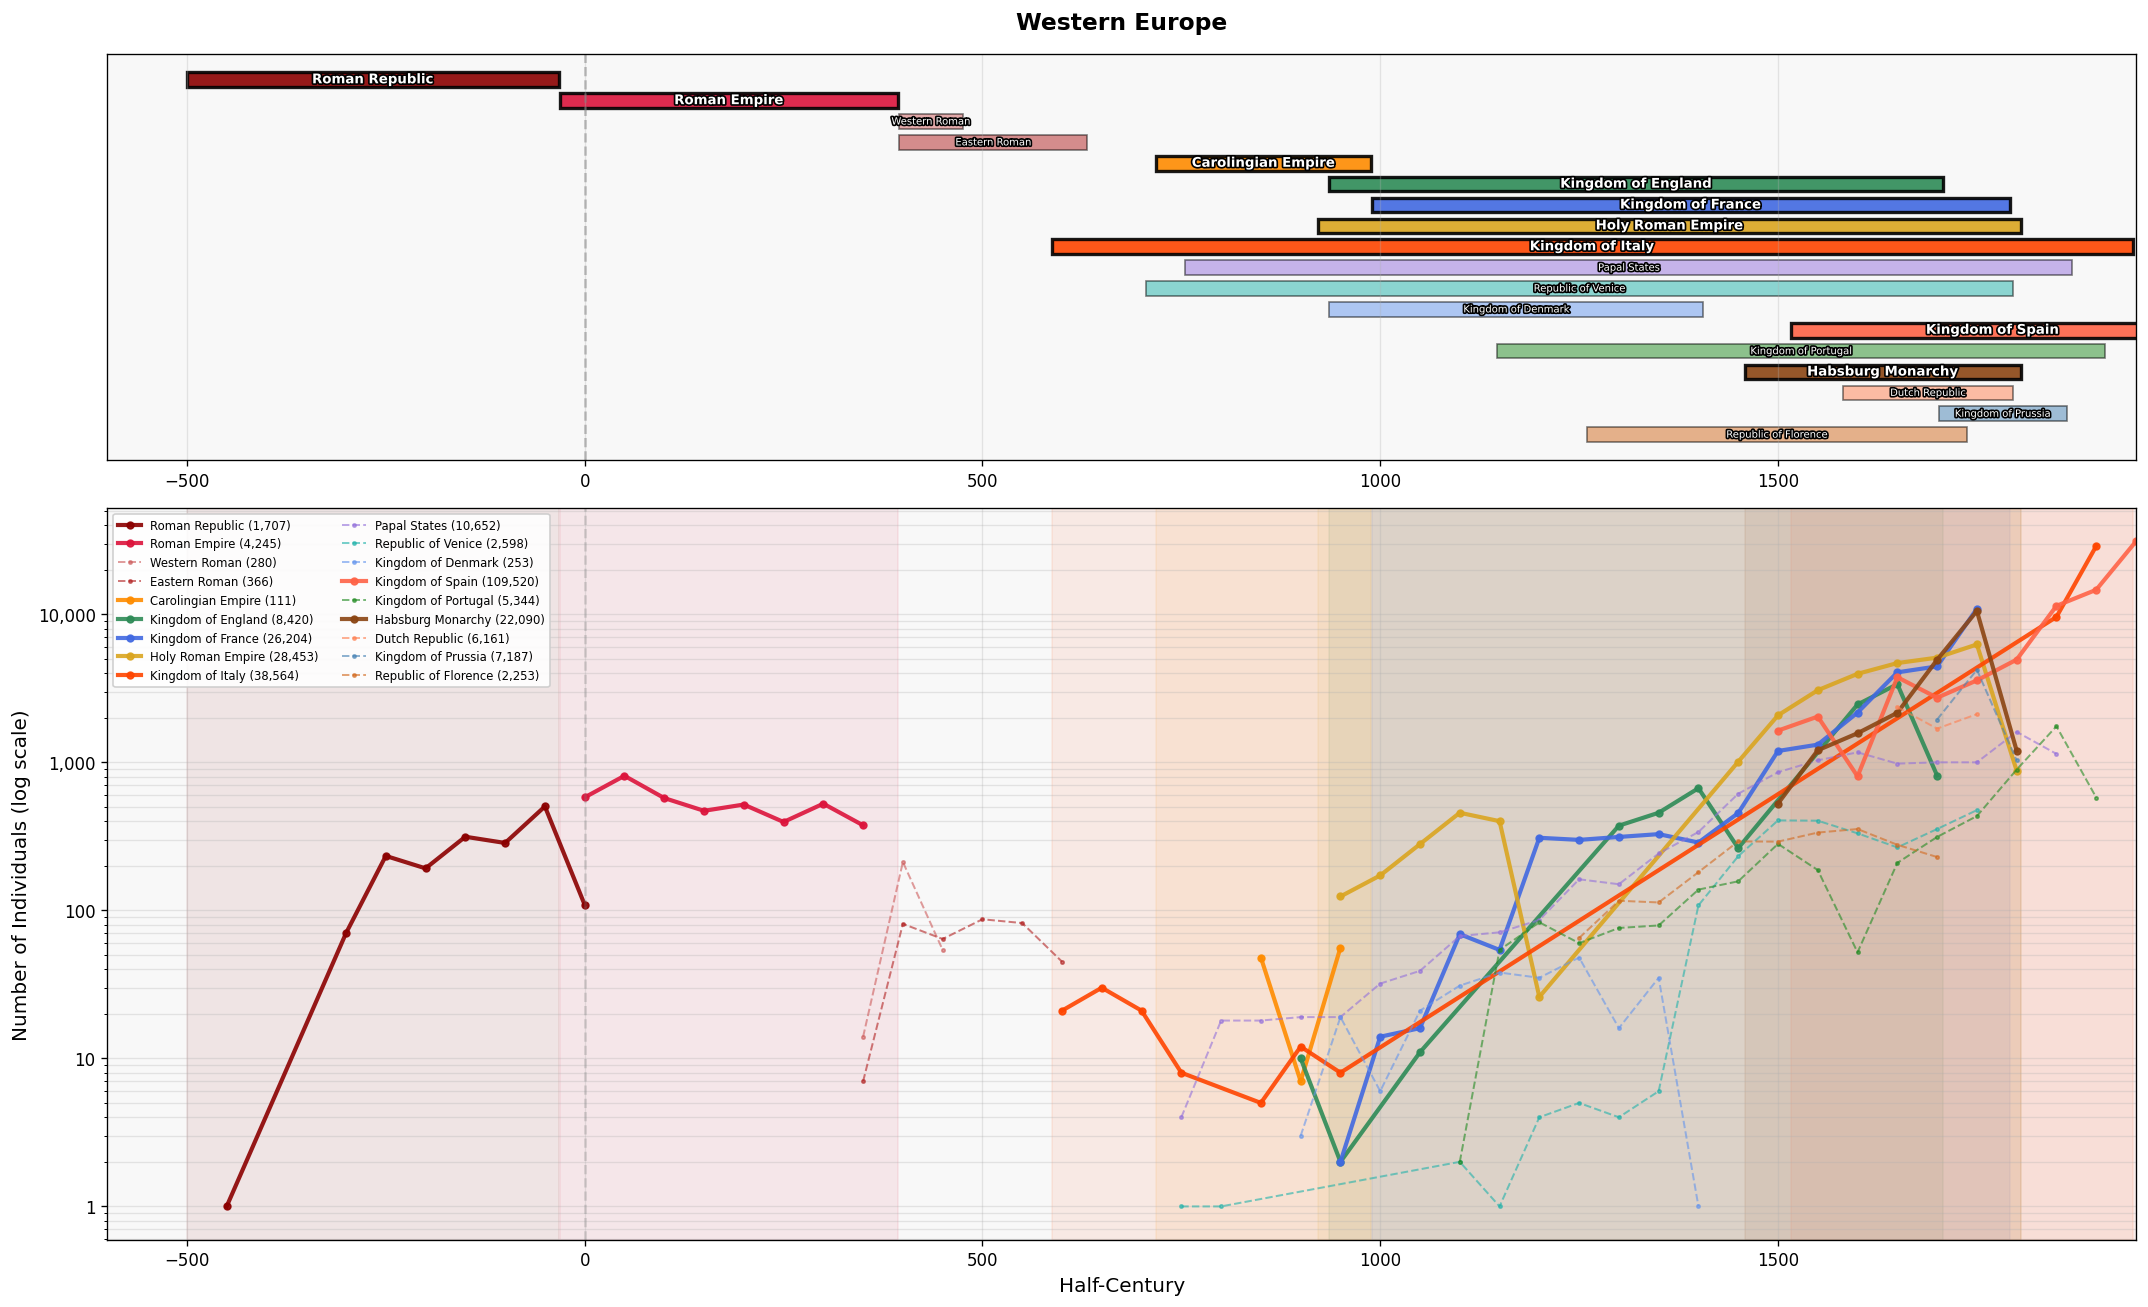

In [4]:
plot_timeline_and_lines(we_data, 'Western Europe', (-600, 1950), save_name='01_western_europe.png')

---
## 2. Eastern Europe

In [5]:
eastern_europe = [
    (380,  'Byzantine Empire',      '#9370DB', True),
    (399,  'First Bulgarian Empire', '#CD853F', False),
    (487,  'Kievan Rus',            '#DC143C', True),
    (561,  'Kingdom of Poland',     '#B22222', False),
    (585,  'Kingdom of Hungary',    '#DAA520', False),
    (712,  'Second Bulgarian Empire','#8B4513', False),
    (725,  'Kingdom of Bohemia',    '#556B2F', False),
    (752,  'Grand Duchy of Lithuania','#228B22', False),
    (1030, 'Tsardom of Russia',     '#4682B4', True),
    (1043, 'Polish-Lithuanian',     '#FF8C00', True),
    (1125, 'Russian Empire',        '#FF4500', True),
    (1391, 'Kingdom of Romania',    '#20B2AA', False),
    (1403, 'Soviet Union',          '#B22222', True),
]
ee_data = load_region_data(conn, eastern_europe)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Byzantine Empire               633 CE - 1474 CE           417      18
  First Bulgarian Empire         682 CE - 1017 CE            43       7
* Kievan Rus                     882 CE - 1240 CE            44       6
  Kingdom of Poland              962 CE - 1449 CE           255       7
  Kingdom of Hungary            1000 CE - 1546 CE           899      11
  Second Bulgarian Empire       1188 CE - 1394 CE            55       5
  Kingdom of Bohemia            1202 CE - 1528 CE           489       7
  Grand Duchy of Lithuania      1220 CE - 1496 CE           103       5


* Tsardom of Russia             1547 CE - 1720 CE         1,481       5


* Polish-Lithuanian             1572 CE - 1793 CE        10,870       5


* Russian Empire                1721 CE - 1916 CE        59,099       5
  Kingdom of Romania            1919 CE - 1947 CE         4,325       1


* Soviet Union                  1922 CE - 1991 CE       256,342       2


  Saved: dynasty_plots/02_eastern_europe.png


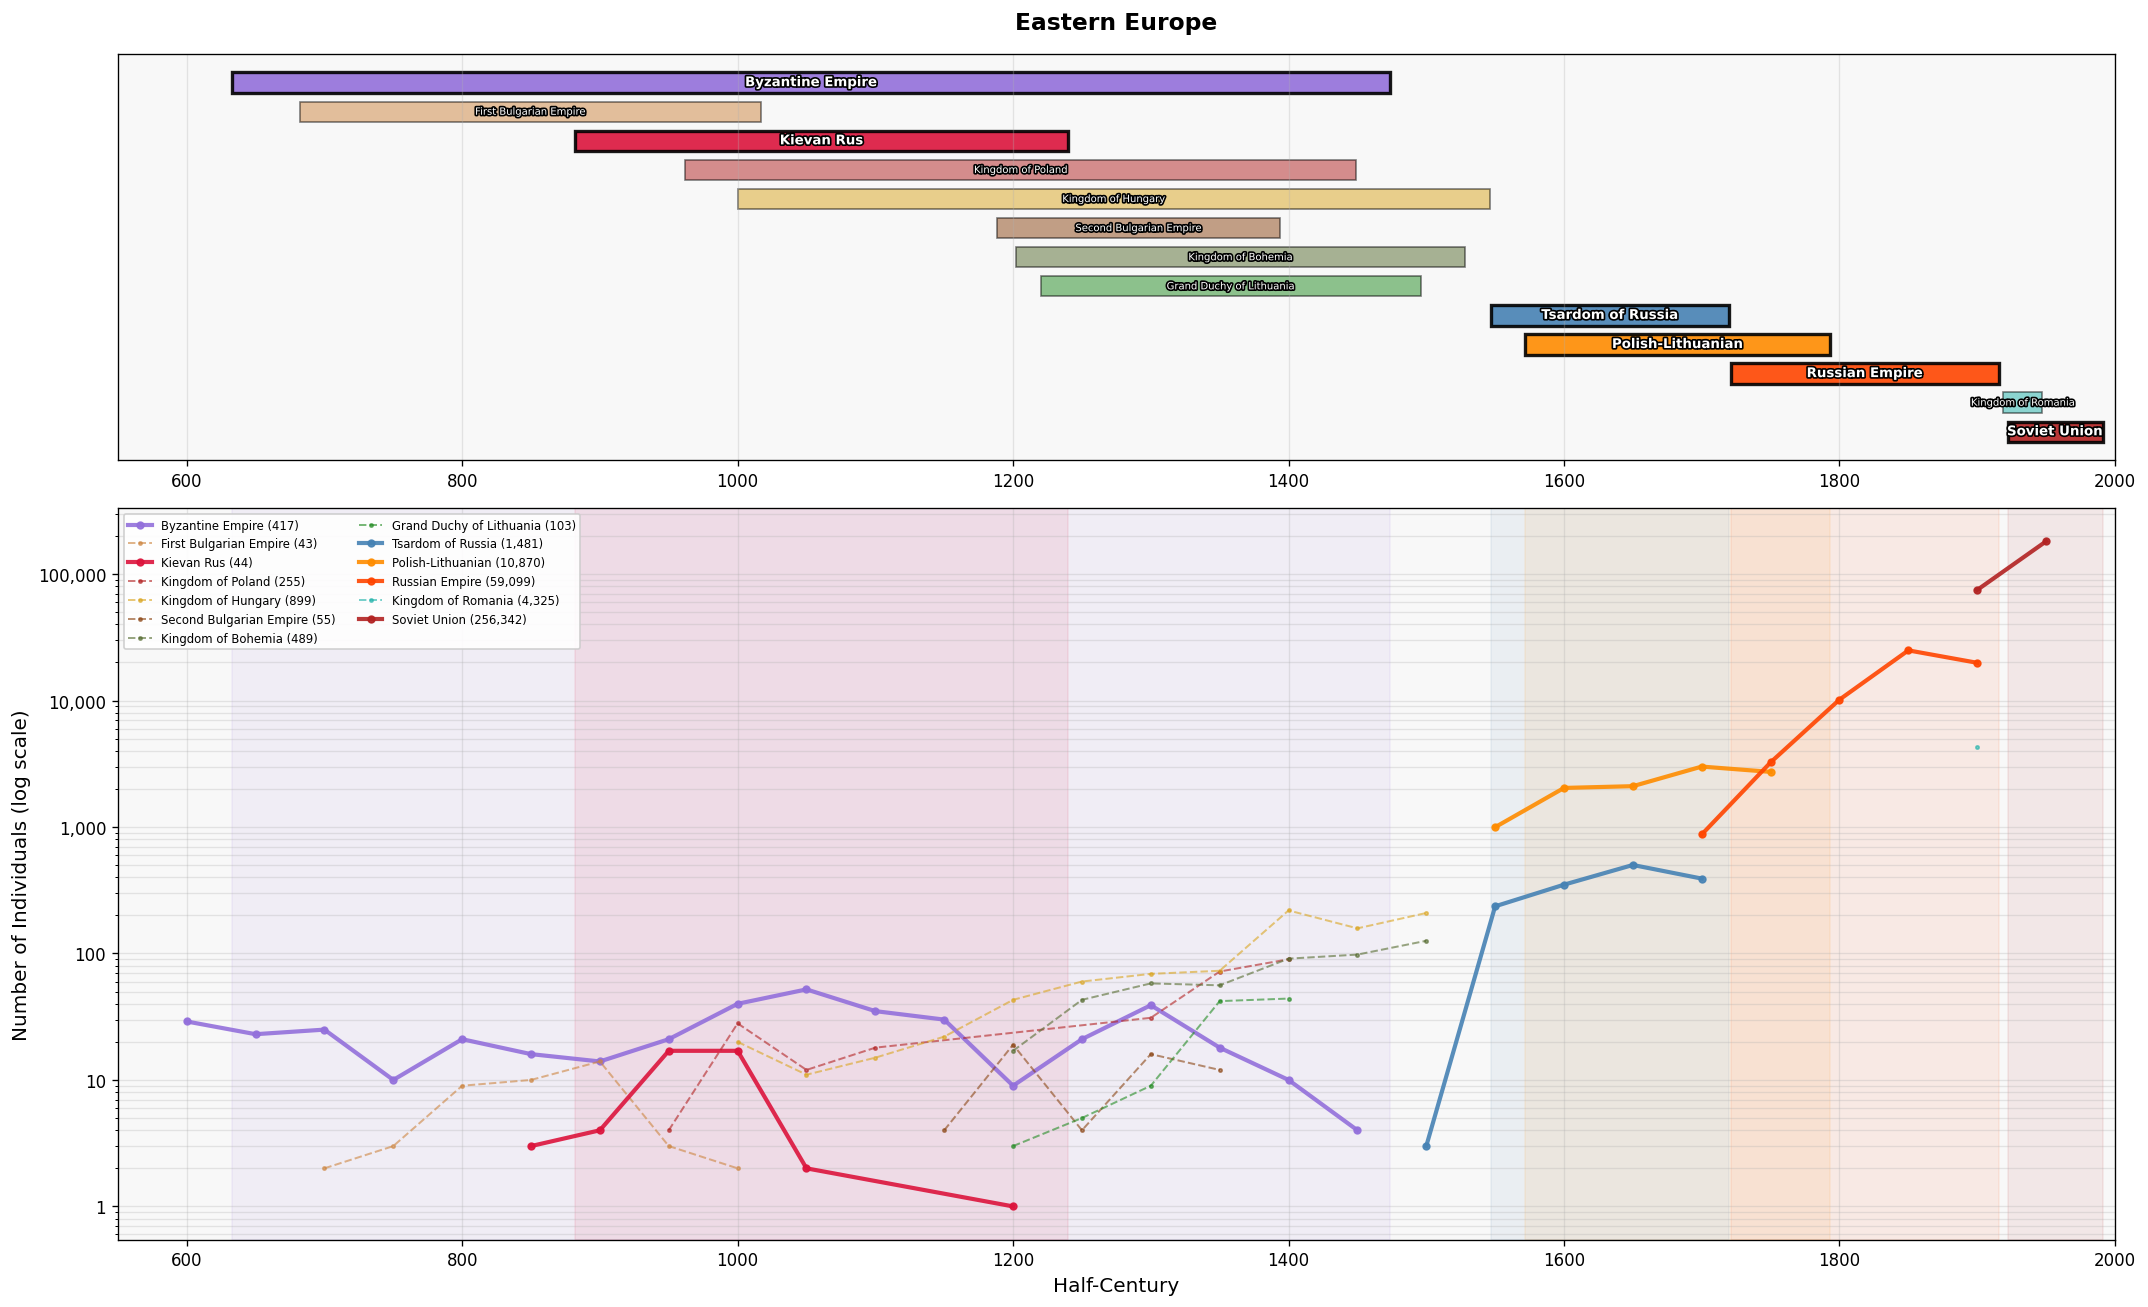

In [6]:
plot_timeline_and_lines(ee_data, 'Eastern Europe', (550, 2000), save_name='02_eastern_europe.png')

---
## 3. Arab & Islamic World

In [7]:
arab_islamic = [
    (379,  'Rashidun Caliphate',  '#2E8B57', True),
    (388,  'Umayyad Caliphate',  '#DAA520', True),
    (419,  'Abbasid Caliphate',  '#FF8C00', True),
    (436,  'Idrisids',           '#CD853F', False),
    (489,  'Samanid Empire',     '#6495ED', False),
    (510,  'Fatimid Caliphate',  '#9370DB', False),
    (544,  'Buyid Dynasty',      '#708090', False),
    (560,  'Ghaznavid Empire',   '#CD853F', False),
    (624,  'Great Seljuk Empire','#B22222', True),
    (638,  'Almoravid Dynasty',  '#556B2F', False),
    (693,  'Almohad Caliphate',  '#228B22', False),
    (709,  'Ayyubid Sultanate',  '#4682B4', False),
    (764,  'Mamluk Sultanate',   '#8B4513', False),
    (903,  'Timurid Empire',     '#DC143C', False),
    (842,  'Ottoman Empire',     '#FF4500', True),
    (993,  'Safavid Dynasty',    '#4169E1', True),
    (1165, 'Qajar Dynasty',      '#FFD700', False),
]
ai_data = load_region_data(conn, arab_islamic)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Rashidun Caliphate             633 CE - 665 CE           140       2


* Umayyad Caliphate              656 CE - 756 CE           491       3
* Abbasid Caliphate              750 CE - 1259 CE           965       7


  Idrisids                       793 CE - 979 CE            10       4
  Samanid Empire                 886 CE - 999 CE           108       3
  Fatimid Caliphate              911 CE - 1176 CE           157       6
  Buyid Dynasty                  936 CE - 1055 CE           129       4
  Ghaznavid Empire               962 CE - 1209 CE            85       5
* Great Seljuk Empire           1040 CE - 1201 CE           434       5


  Almoravid Dynasty             1056 CE - 1205 CE            99       4
  Almohad Caliphate             1139 CE - 1343 CE           124       5
  Ayyubid Sultanate             1177 CE - 1249 CE           238       2
  Mamluk Sultanate              1241 CE - 1518 CE           578       7


  Timurid Empire                1375 CE - 1506 CE           156       4


* Ottoman Empire                1305 CE - 1923 CE        12,050      13
* Safavid Dynasty               1502 CE - 1737 CE           418       5
  Qajar Dynasty                 1788 CE - 1923 CE         1,061       4


  Saved: dynasty_plots/03_arab_islamic.png


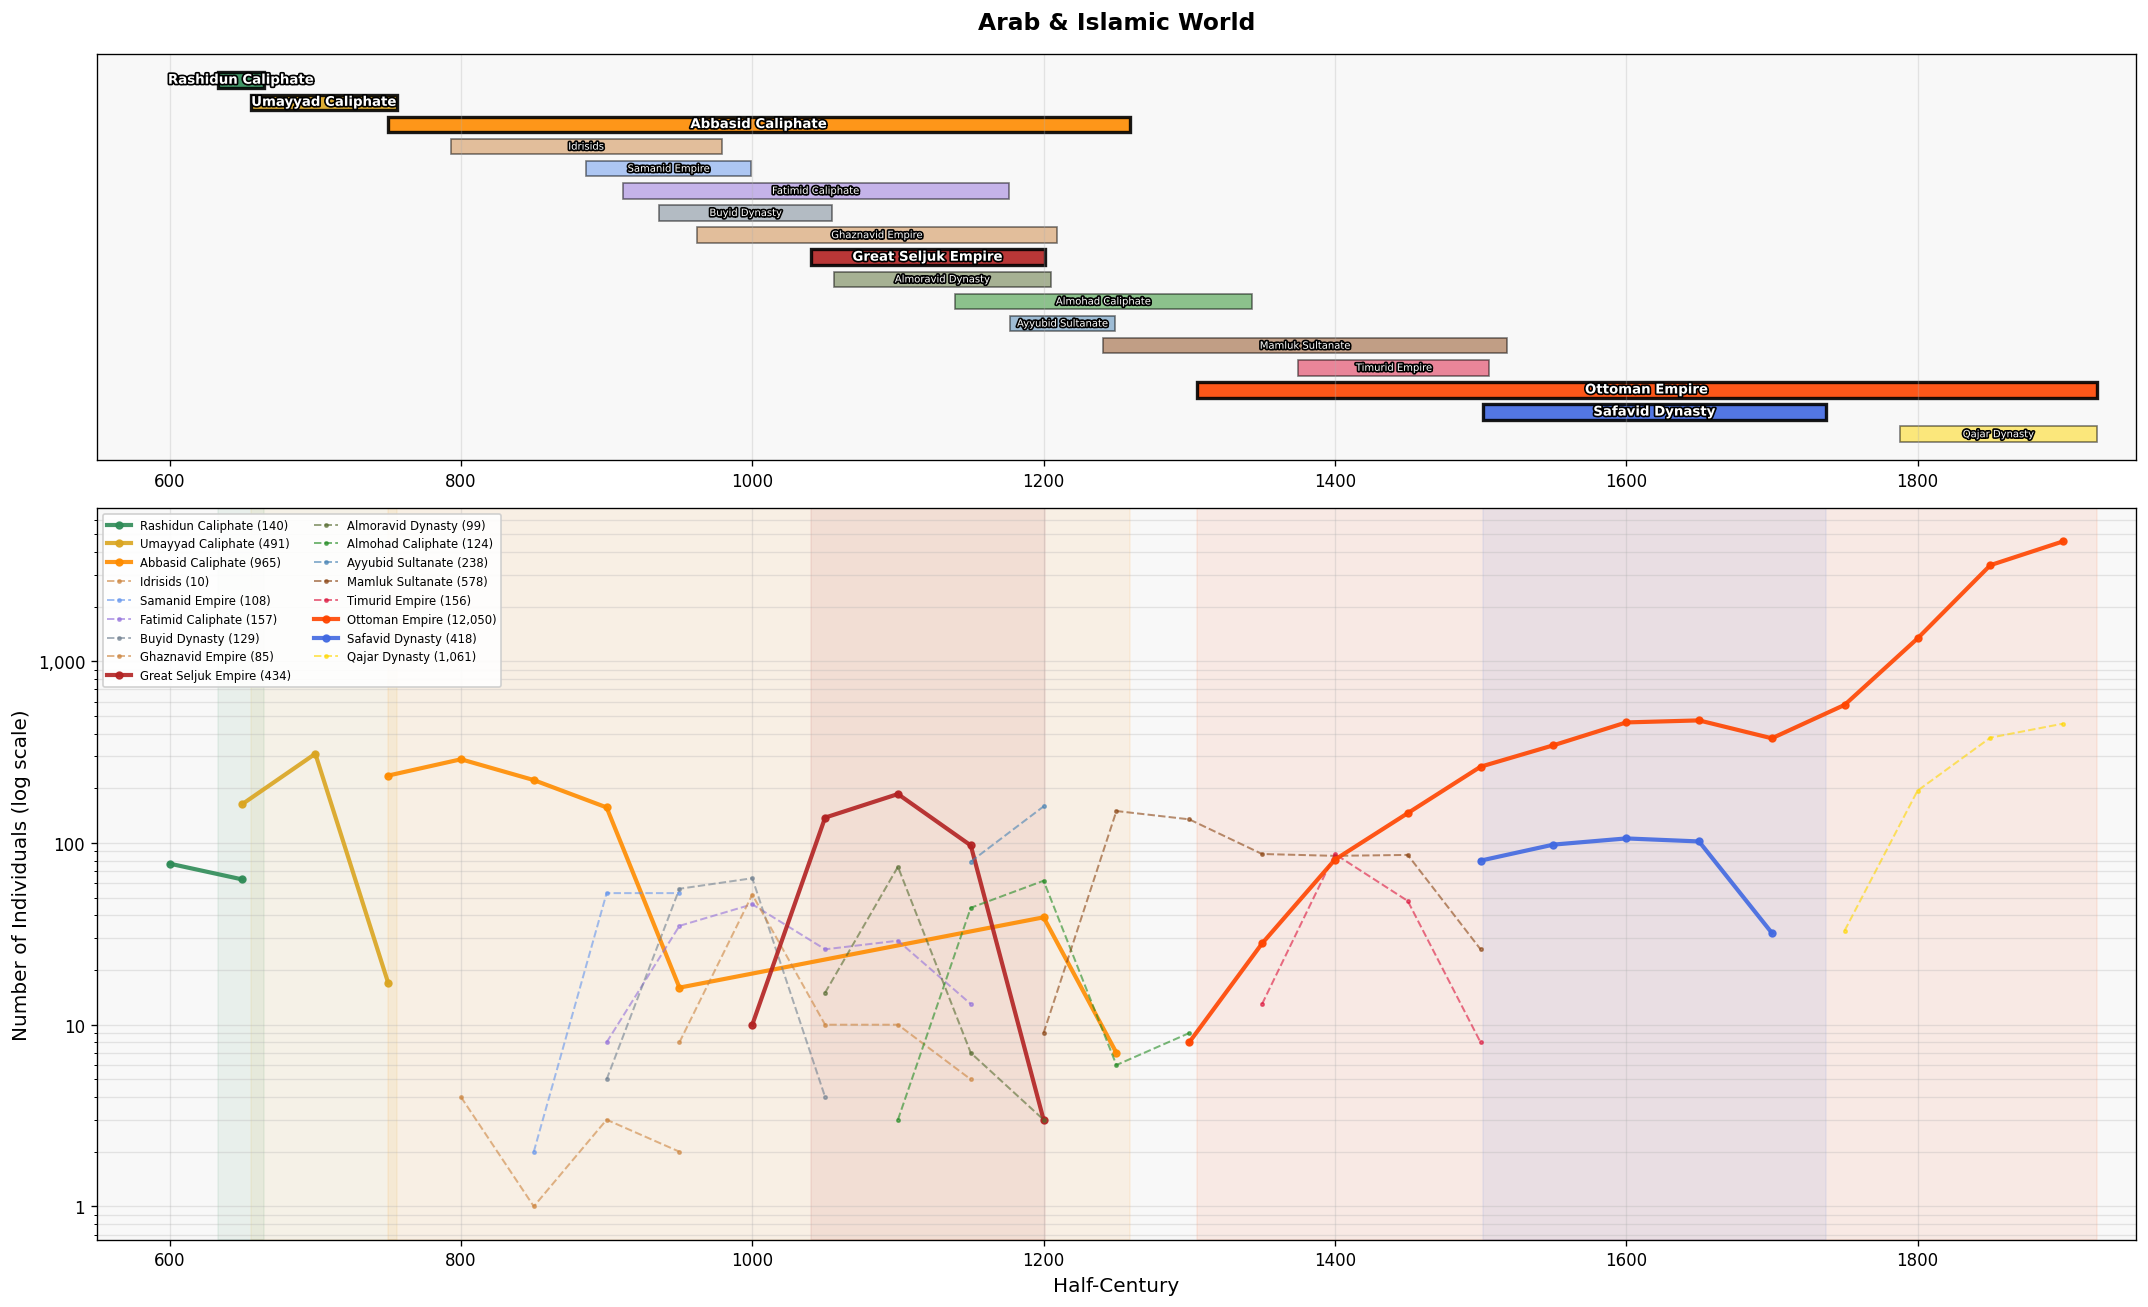

In [8]:
plot_timeline_and_lines(ai_data, 'Arab & Islamic World', (550, 1950), save_name='03_arab_islamic.png')

---
## 4. Mesopotamia & Ancient Persia

In [9]:
mesopotamia = [
    (1,    'Sumerian City-States','#8B4513', True),
    (6,    'Akkadian Empire',    '#DAA520', True),
    (13,   'Babylonia',          '#DC143C', True),
    (11,   'Assyria',            '#B22222', True),
    (31,   'Neo-Assyrian Empire','#FF8C00', True),
    (73,   'Neo-Babylonian',     '#4169E1', True),
    (89,   'Achaemenid Empire',  '#FF4500', True),
    (125,  'Seleucid Empire',    '#9370DB', False),
    (150,  'Parthian Empire',    '#228B22', False),
    (229,  'Sasanian Empire',    '#8B0000', True),
]
meso_data = load_region_data(conn, mesopotamia)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Sumerian City-States          3400 BCE - 1761 BCE            21      10
* Akkadian Empire               2300 BCE - 2101 BCE             8       5
* Babylonia                     1800 BCE - 601 BCE            52      18
* Assyria                       1800 BCE - 901 BCE            22       9
* Neo-Assyrian Empire           900 BCE - 601 BCE            55       7
* Neo-Babylonian                600 BCE - 531 BCE            21       3
* Achaemenid Empire             550 BCE - 327 BCE           223       5
  Seleucid Empire               318 BCE - 64 BCE           105       6
  Parthian Empire               239 BCE - 237 CE            88       7
* Sasanian Empire                215 CE - 643 CE           352       9


  Saved: dynasty_plots/04_mesopotamia_persia.png


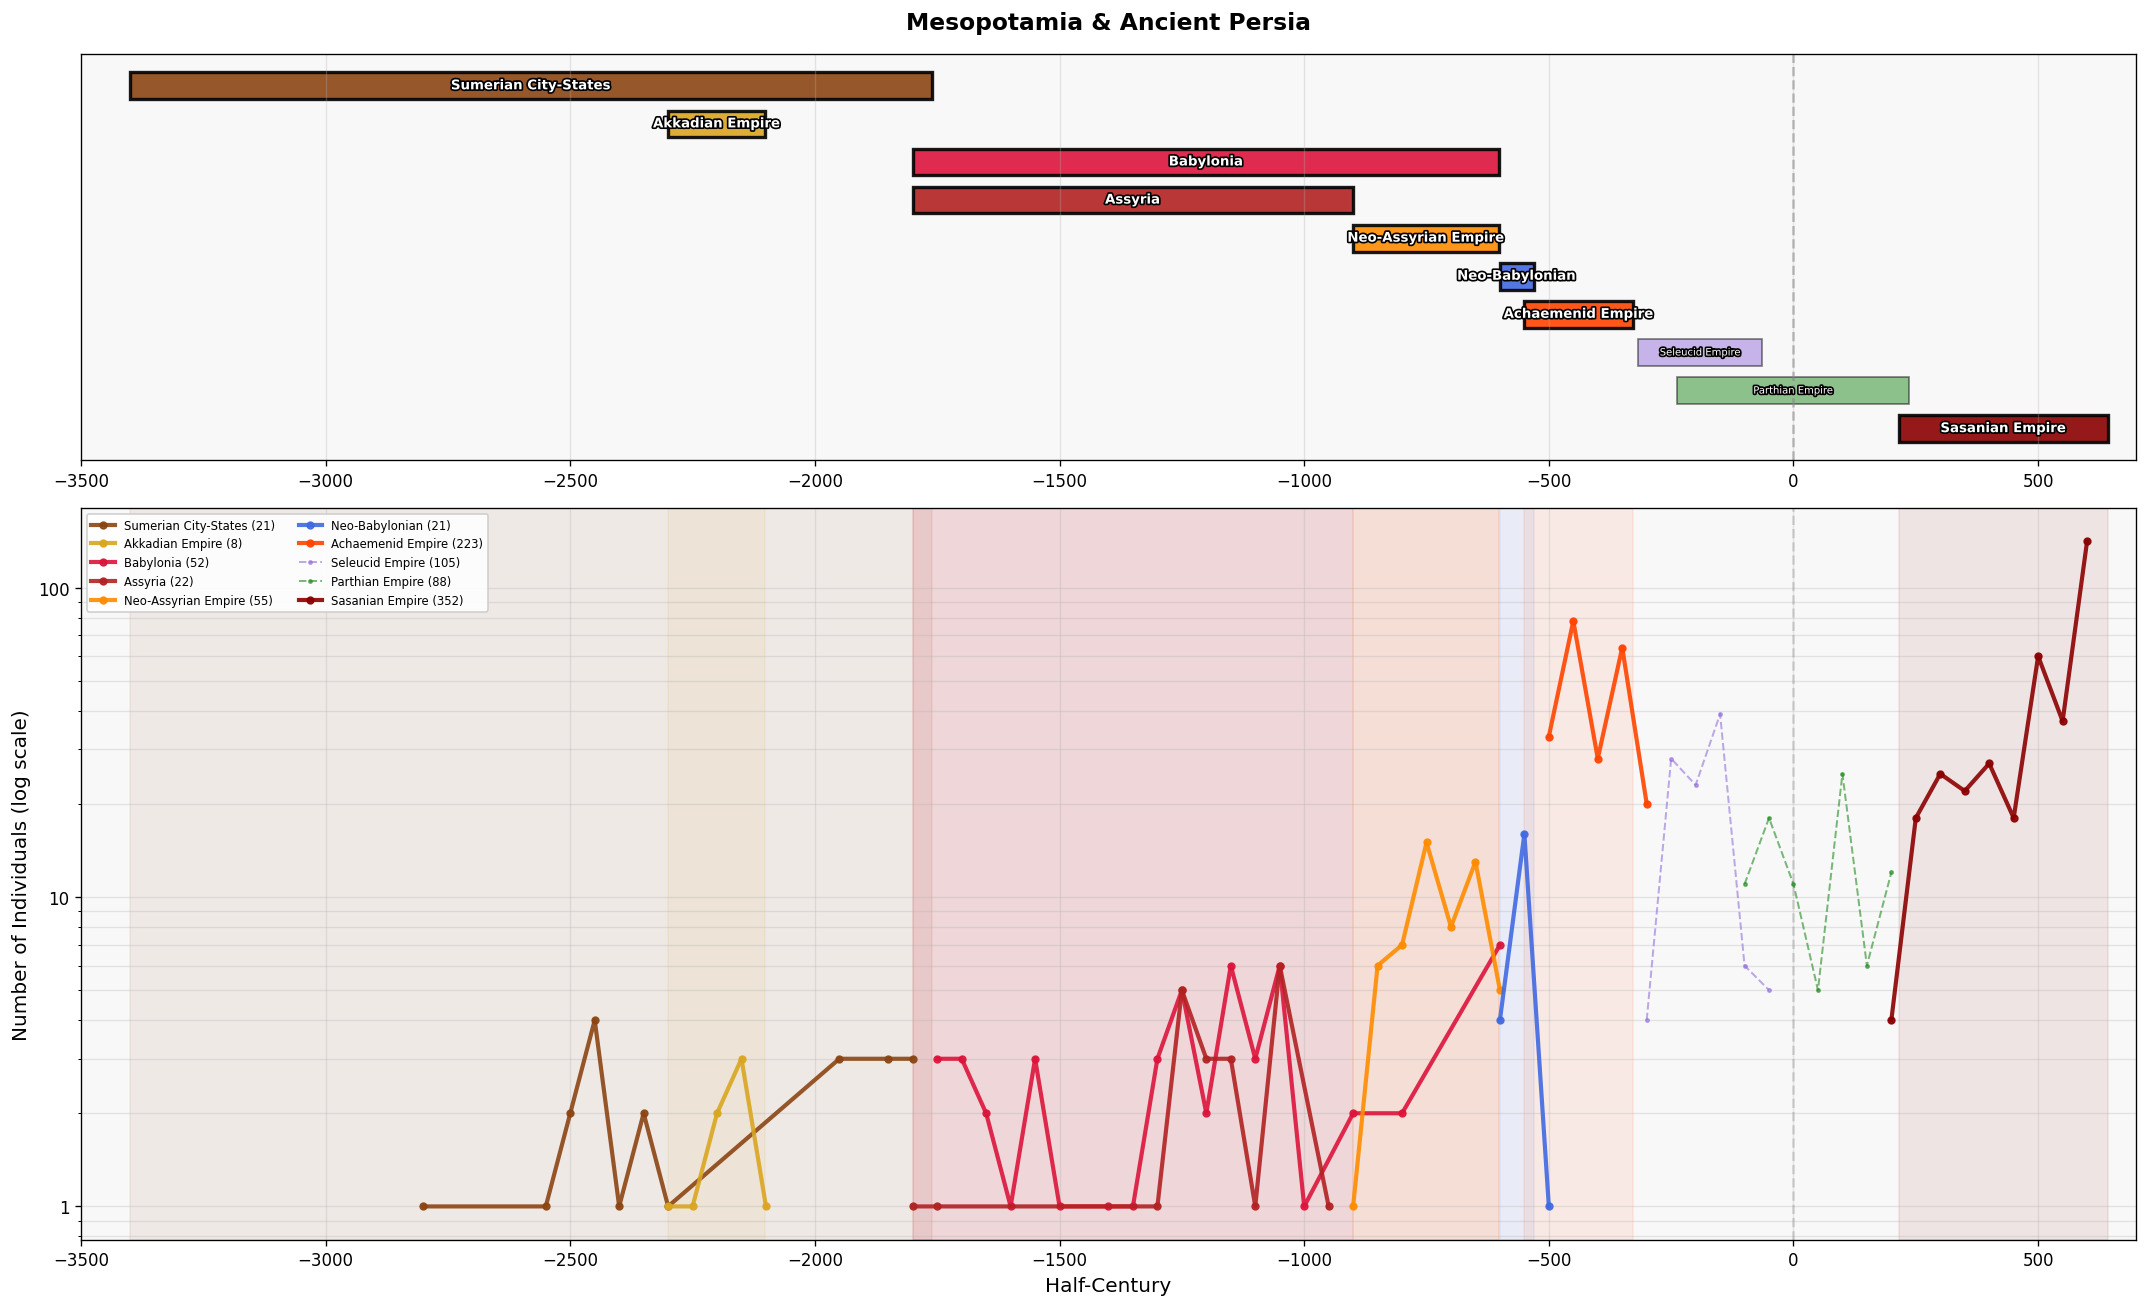

In [10]:
plot_timeline_and_lines(meso_data, 'Mesopotamia & Ancient Persia', (-3500, 700), save_name='04_mesopotamia_persia.png')

---
## 5. Indian World

In [11]:
indian = [
    (124,  'Maurya Empire',       '#FF8C00', True),
    (213,  'Kushan Empire',       '#8B4513', False),
    (250,  'Gupta Empire',        '#DAA520', True),
    (424,  'Rashtrakuta Dynasty', '#708090', False),
    (458,  'Chola Empire',        '#B22222', False),
    (673,  'Hoysala Kingdom',     '#556B2F', False),
    (746,  'Delhi Sultanate',     '#4169E1', True),
    (877,  'Vijayanagara Empire', '#228B22', True),
    (988,  'Mughal Empire',       '#DC143C', True),
    (1038, 'Kingdom of Mysore',   '#20B2AA', False),
    (1096, 'Maratha Empire',      '#FF4500', False),
    (1182, 'Sikh Empire',         '#FFD700', False),
    (1330, 'British Raj',         '#4682B4', True),
]
india_data = load_region_data(conn, indian)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Maurya Empire                 318 BCE - 171 BCE            19       4
  Kushan Empire                   43 CE - 237 CE            10       3
* Gupta Empire                   324 CE - 554 CE            10       4
  Rashtrakuta Dynasty            755 CE - 989 CE             7       4
  Chola Empire                   850 CE - 1259 CE            30       7
  Hoysala Kingdom               1111 CE - 1351 CE            12       5
* Delhi Sultanate               1210 CE - 1528 CE            89       7
* Vijayanagara Empire           1344 CE - 1571 CE            57       5
* Mughal Empire                 1497 CE - 1858 CE           491       9
  Kingdom of Mysore             1572 CE - 1799 CE            24       5
  Maratha Empire                1677 CE - 1845 CE            80       3
  Sikh Empire                   1799 CE - 1848 CE            42      

* British Raj                   1859 CE - 1947 CE        10,089       2


  Saved: dynasty_plots/05_indian_world.png


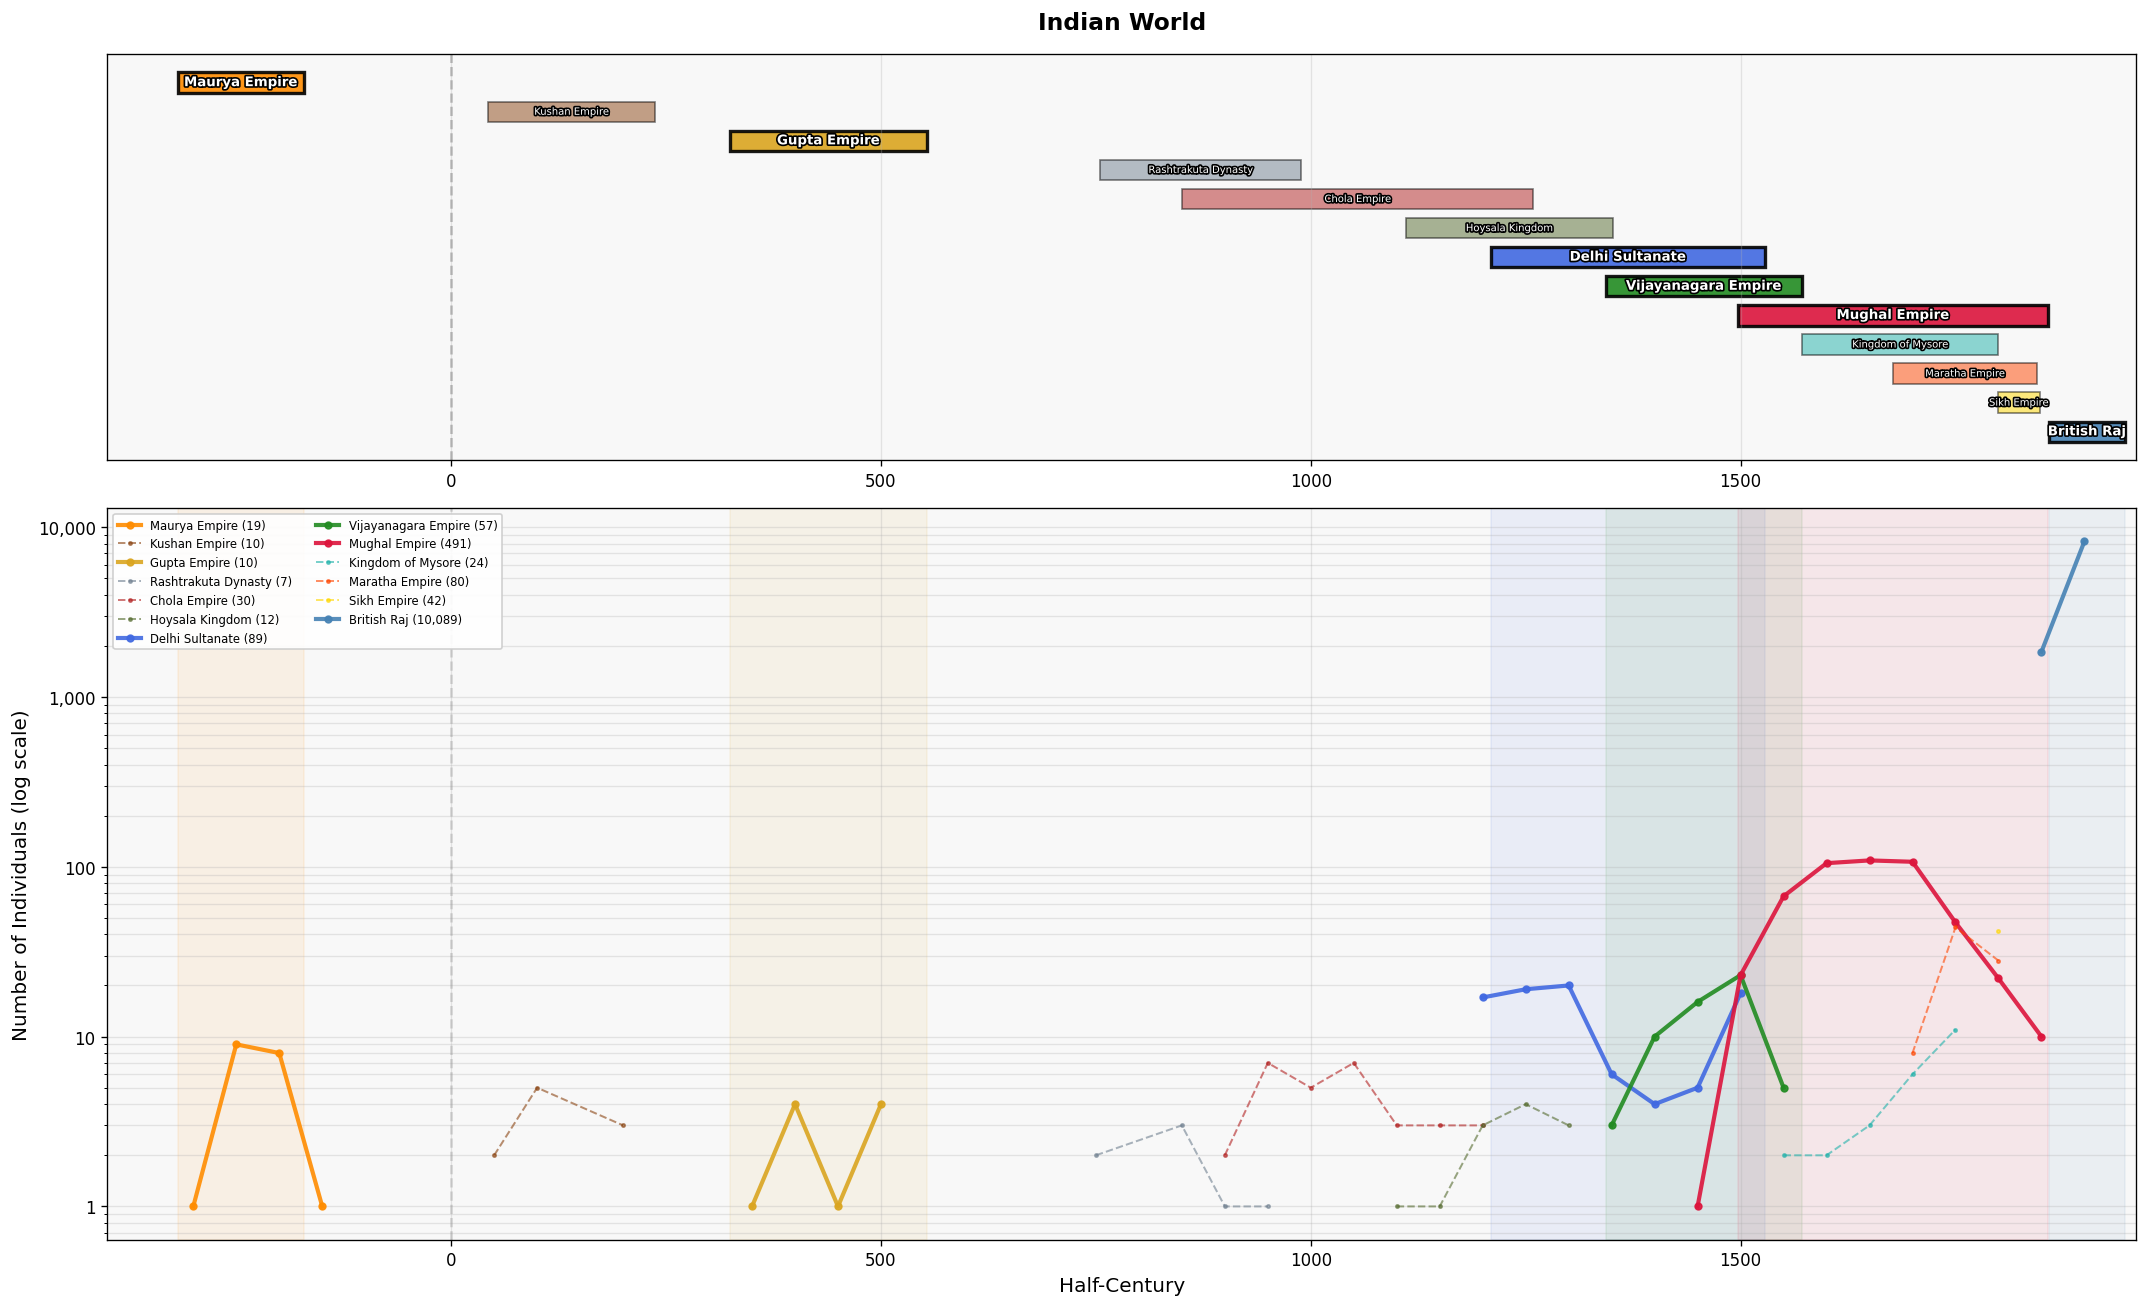

In [12]:
plot_timeline_and_lines(india_data, 'Indian World', (-400, 1960), save_name='05_indian_world.png')

---
## 6. East Asia (Japan & Korea)

In [13]:
east_asia = [
    (206,  'Goguryeo',            '#8B4513', False),
    (265,  'Silla',               '#CD853F', False),
    (257,  'Baekje',              '#556B2F', False),
    (330,  'Yamato',              '#DC143C', True),
    (397,  'Unified Silla',       '#DAA520', False),
    (530,  'Goryeo',              '#4169E1', True),
    (716,  'Kamakura Shogunate',  '#B22222', False),
    (734,  'Mongol Empire',       '#FF8C00', True),
    (875,  'Ashikaga Shogunate',  '#228B22', False),
    (916,  'Joseon',              '#9370DB', True),
    (969,  'Warring States Japan','#708090', False),
    (1054, 'Tokugawa Shogunate',  '#FF4500', True),
    (1340, 'Empire of Japan',     '#8B0000', True),
]
ea_data = load_region_data(conn, east_asia)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Goguryeo                       36 BCE - 681 CE            47      13
  Silla                          378 CE - 681 CE            54       7
  Baekje                         347 CE - 660 CE            42       7
* Yamato                         540 CE - 1187 CE           949      14
  Unified Silla                  682 CE - 935 CE            66       6
* Goryeo                         922 CE - 1394 CE           370       9
  Kamakura Shogunate            1188 CE - 1332 CE           545       4


* Mongol Empire                 1206 CE - 1293 CE         1,859       2
  Ashikaga Shogunate            1344 CE - 1571 CE           419       5
* Joseon                        1395 CE - 1897 CE         2,585      11
  Warring States Japan          1468 CE - 1601 CE         1,548       4


* Tokugawa Shogunate            1600 CE - 1869 CE         8,256       6


* Empire of Japan               1868 CE - 1945 CE        36,111       2


  Saved: dynasty_plots/06_east_asia.png


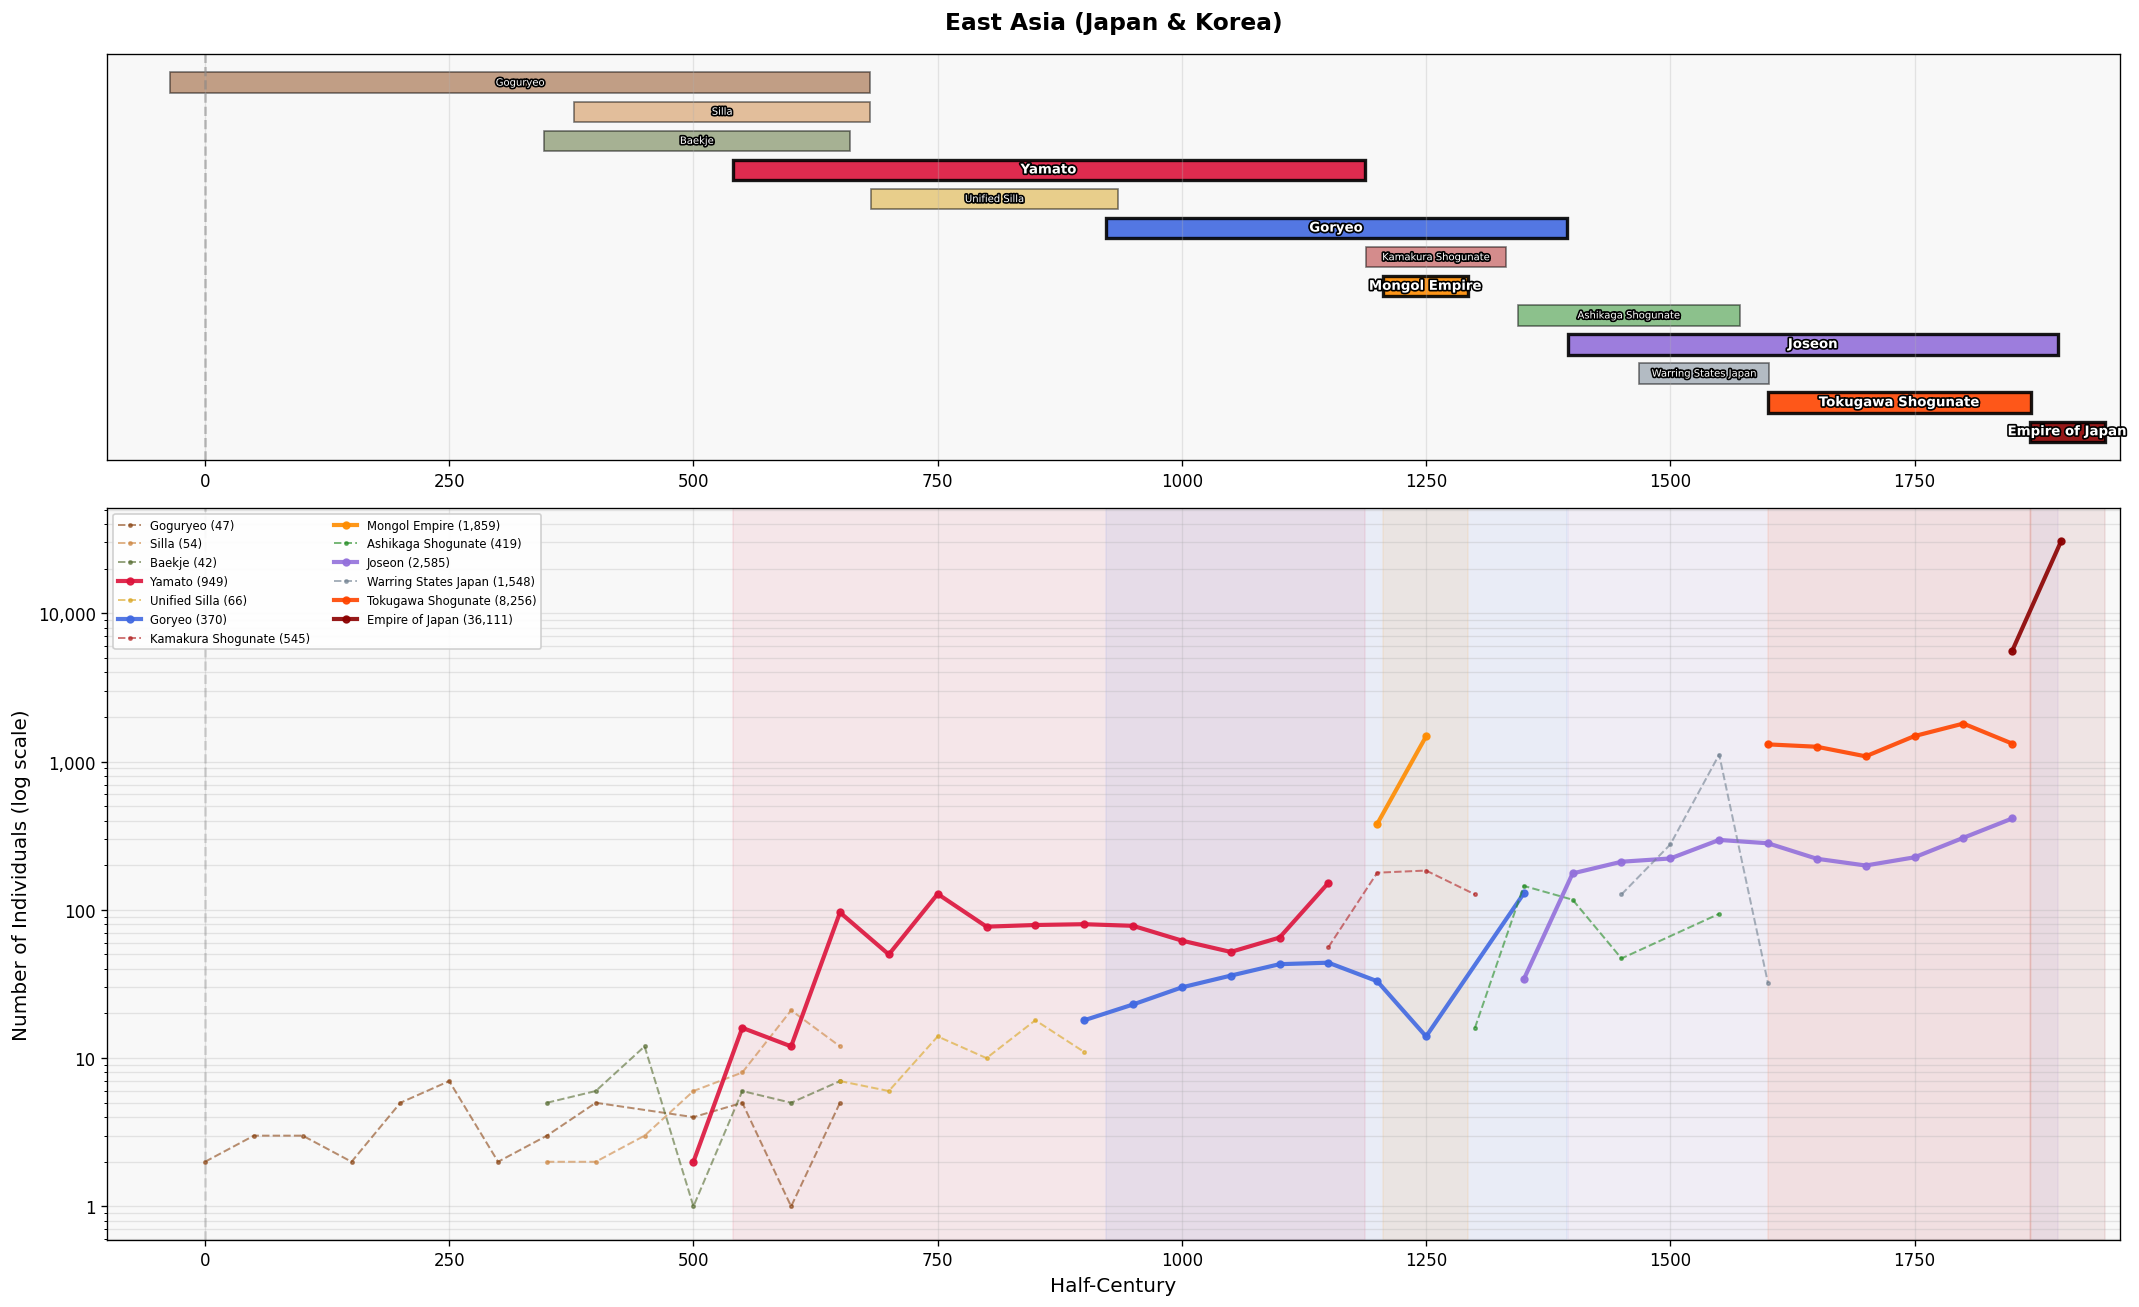

In [14]:
plot_timeline_and_lines(ea_data, 'East Asia (Japan & Korea)', (-100, 1960), save_name='06_east_asia.png')

---
## 7. Southeast Asia

In [15]:
southeast_asia = [
    (223,  'Champa',              '#CD853F', False),
    (394,  'Srivijaya',           '#20B2AA', False),
    (440,  'Khmer Empire',        '#DC143C', True),
    (456,  'Pagan Kingdom',       '#DAA520', True),
    (766,  'Sukhothai Kingdom',   '#4169E1', False),
    (814,  'Majapahit',           '#228B22', True),
    (882,  'Ayutthaya Kingdom',   '#FF8C00', True),
    (897,  'Lan Xang',            '#9370DB', False),
    (885,  'Sultanate of Brunei', '#556B2F', False),
    (994,  'Toungoo Empire',      '#B22222', False),
    (1136, 'Konbaung Dynasty',    '#8B4513', False),
    (1163, 'Rattanakosin',        '#FF4500', True),
    (1185, 'Dutch East Indies',   '#FF7F50', False),
    (1418, 'Kingdom of Thailand', '#FFD700', True),
    (1445, 'Republic of Indonesia','#DC143C', True),
    (1451, 'Republic of Philippines','#4169E1', True),
    (1516, 'Malaysia',            '#228B22', False),
]
sea_data = load_region_data(conn, southeast_asia)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Champa                         197 CE - 1652 CE            47      12
  Srivijaya                      674 CE - 1293 CE             5       3
* Khmer Empire                   800 CE - 1867 CE            64      21
* Pagan Kingdom                  850 CE - 1293 CE            55       9
  Sukhothai Kingdom             1241 CE - 1458 CE            15       4
* Majapahit                     1294 CE - 1518 CE            15       4
* Ayutthaya Kingdom             1352 CE - 1768 CE            78       9
  Lan Xang                      1363 CE - 1708 CE            31       7
  Sultanate of Brunei           1363 CE - 2024 CE           189      11
  Toungoo Empire                1502 CE - 1761 CE            60       5
  Konbaung Dynasty              1741 CE - 1819 CE            24       3
* Rattanakosin                  1783 CE - 1931 CE           586   

  Dutch East Indies             1800 CE - 1949 CE         1,942       3


* Kingdom of Thailand           1932 CE - 2024 CE         7,990       3


* Republic of Indonesia         1946 CE - 2024 CE        20,676       3
* Republic of Philippines       1947 CE - 2024 CE         3,593       3


  Malaysia                      1963 CE - 2024 CE         5,747       2


  Saved: dynasty_plots/07_southeast_asia.png


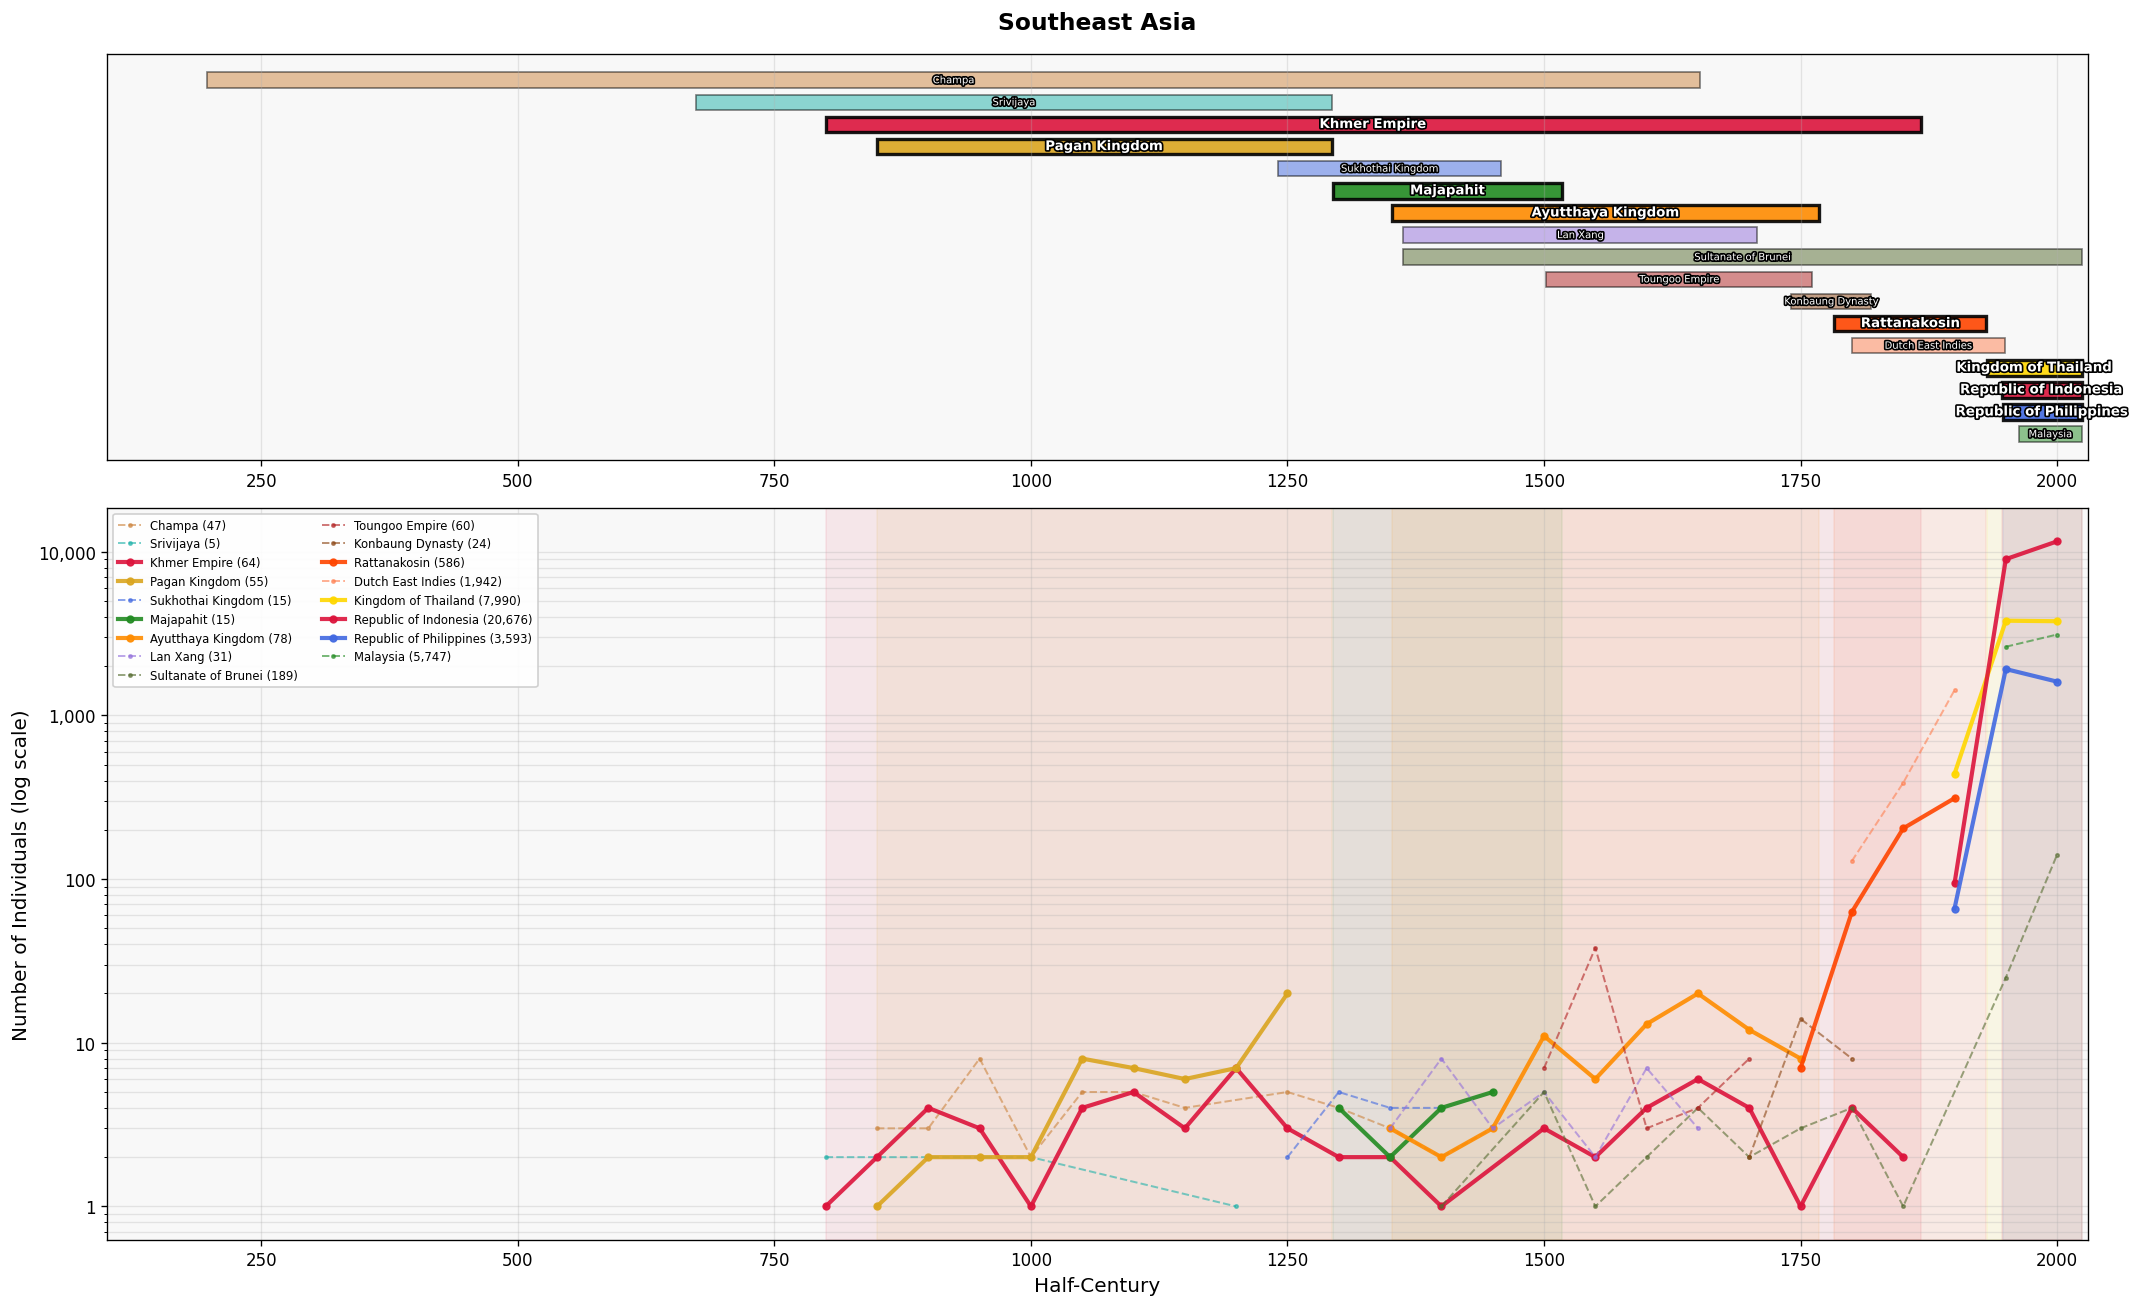

In [16]:
plot_timeline_and_lines(sea_data, 'Southeast Asia', (100, 2030), save_name='07_southeast_asia.png')

---
## 8. Africa

In [17]:
africa = [
    (3,    'Early Dynastic Egypt','#DAA520', False),
    (5,    'Old Kingdom Egypt',   '#CD853F', False),
    (10,   'Middle Kingdom Egypt','#B8860B', False),
    (23,   'New Kingdom Egypt',   '#FF8C00', True),
    (29,   'Kingdom of Kush',     '#8B4513', False),
    (115,  'Ptolemaic Kingdom',   '#4169E1', False),
    (205,  'Kingdom of Axum',     '#228B22', True),
    (757,  'Mali Empire',         '#DC143C', True),
    (791,  'Ethiopian Empire',    '#2E8B57', True),
    (941,  'Kingdom of Kongo',    '#9370DB', False),
    (961,  'Songhai Empire',      '#B22222', True),
    (1058, 'Oyo Empire',          '#FF4500', False),
    (1104, 'Ashanti Empire',      '#FFD700', False),
    (1172, 'Merina Kingdom',      '#20B2AA', False),
    (1197, 'Sokoto Caliphate',    '#4682B4', False),
]
africa_data = load_region_data(conn, africa)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Early Dynastic Egypt          3000 BCE - 2501 BCE            41      11
  Old Kingdom Egypt             2500 BCE - 2201 BCE            33       7
  Middle Kingdom Egypt          2000 BCE - 1601 BCE            59       9
* New Kingdom Egypt             1500 BCE - 801 BCE           157      15
  Kingdom of Kush               1000 BCE - 346 CE             8       7
  Ptolemaic Kingdom             331 BCE - 28 BCE           133       7
* Kingdom of Axum                50 BCE - 946 CE            31      11
* Mali Empire                   1236 CE - 1611 CE            32       7
* Ethiopian Empire              1272 CE - 1935 CE           200      12
  Kingdom of Kongo              1440 CE - 1669 CE            23       5
* Songhai Empire                1463 CE - 1608 CE            12       3
  Oyo Empire                    1609 CE - 1835 CE            

  Saved: dynasty_plots/08_africa.png


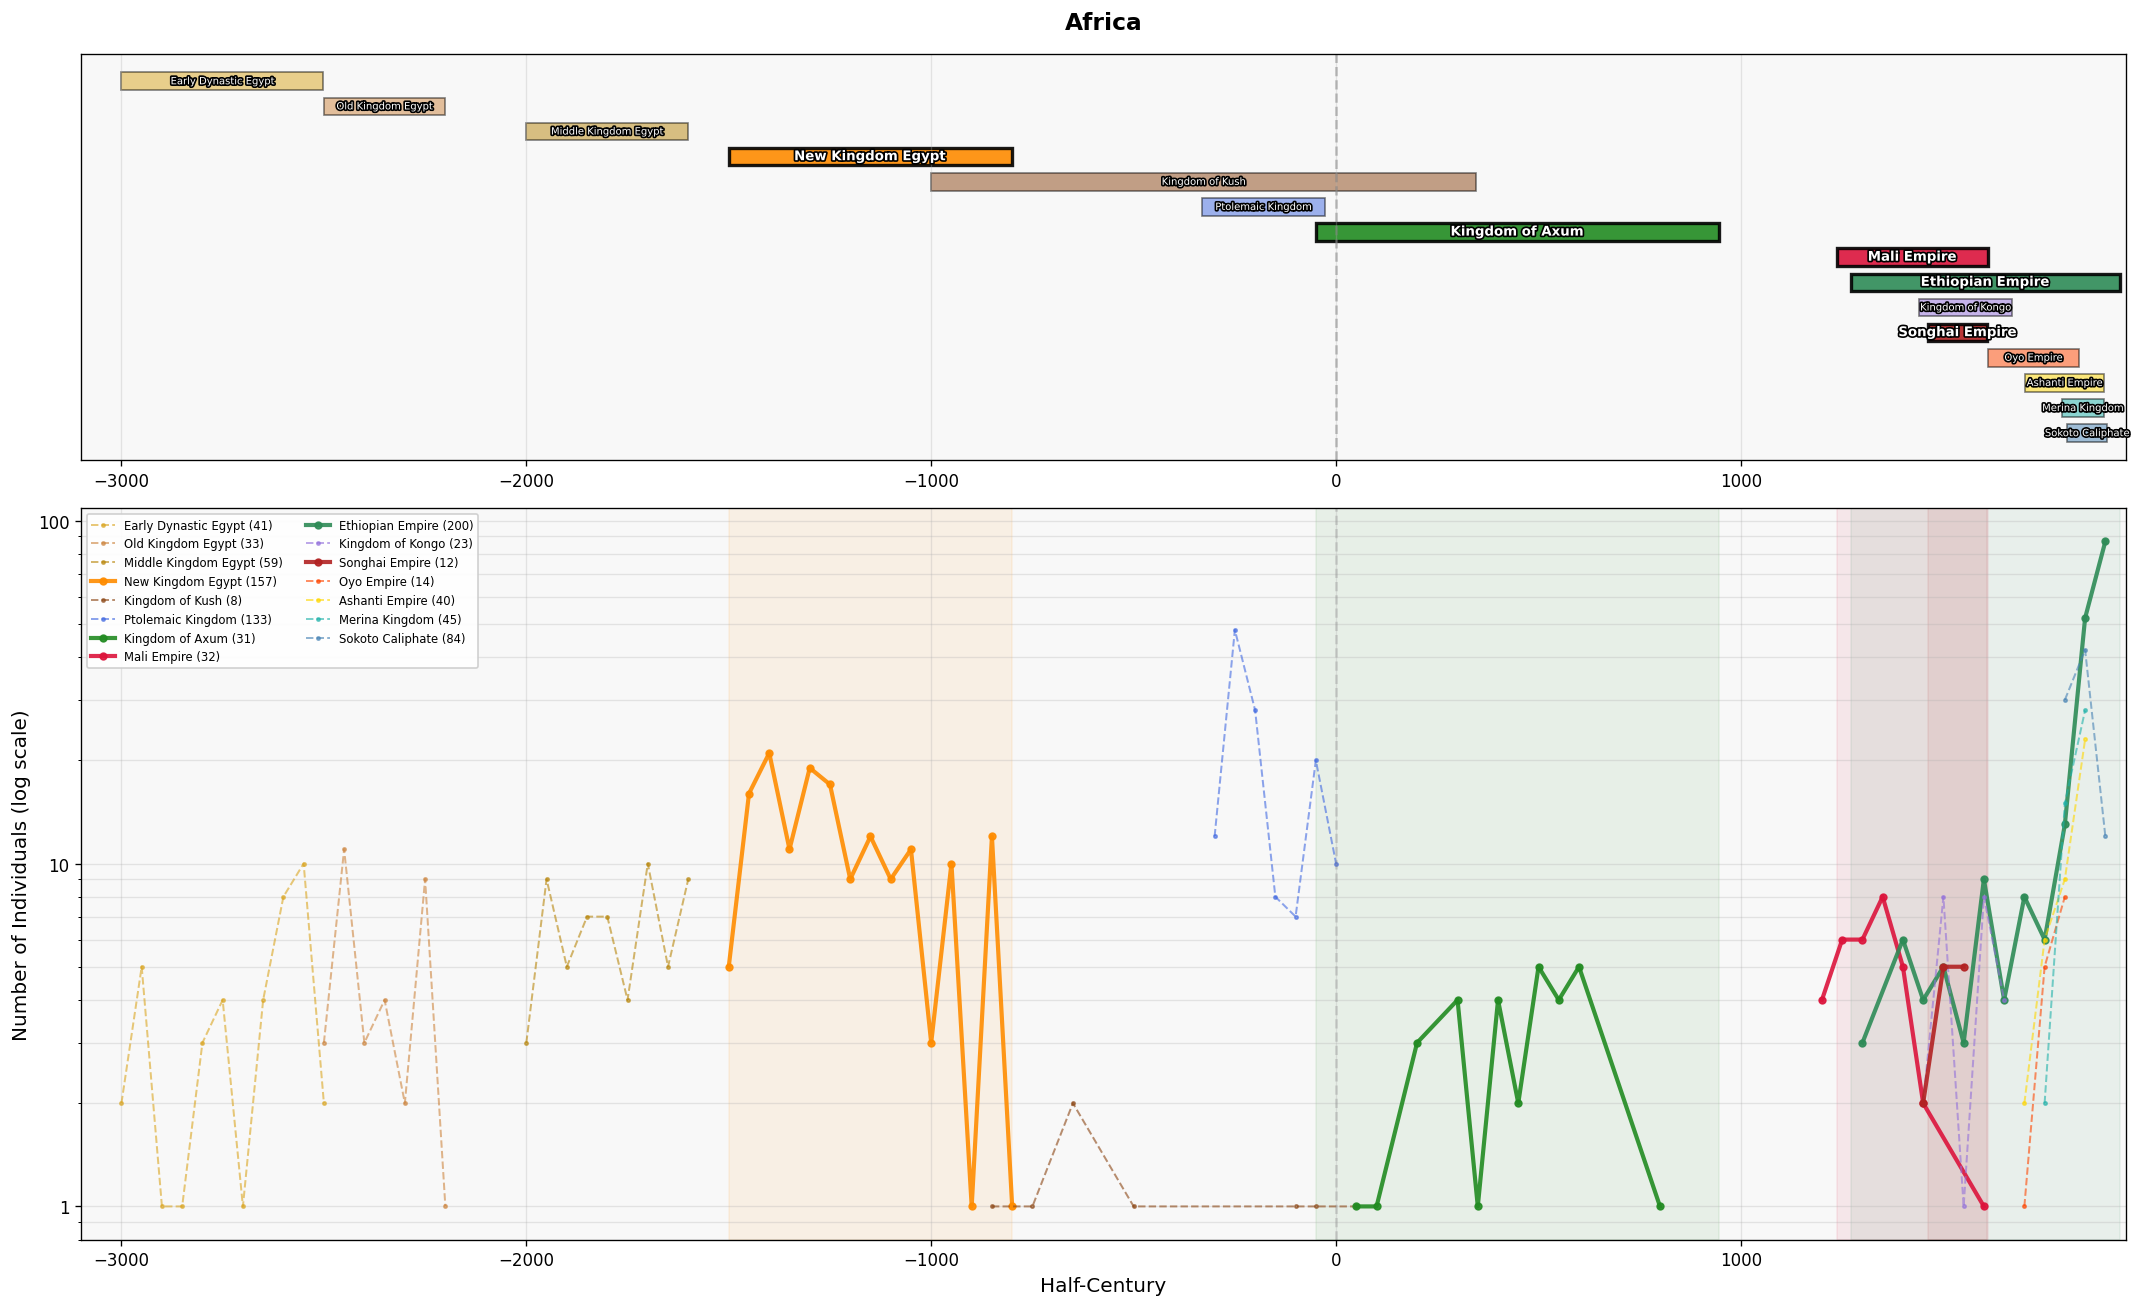

In [18]:
plot_timeline_and_lines(africa_data, 'Africa', (-3100, 1950), save_name='08_africa.png')

---
## 9. North America

In [19]:
north_america = [
    (149,  'Mayan City-States',   '#228B22', True),
    (938,  'Aztec Triple Alliance','#DC143C', True),
    (949,  'Haudenosaunee',       '#8B4513', False),
    (1057, 'New France',          '#4169E1', False),
    (1060, 'English Colonies',    '#2E8B57', False),
    (1273, 'Mexico (early)',      '#FF8C00', False),
    (1159, 'United States',       '#B22222', True),
    (1343, 'Mexico',              '#228B22', True),
    (1417, 'Canada',              '#FF4500', True),
    (1491, 'Cuba',                '#DAA520', False),
]
na_data = load_region_data(conn, north_america)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Mayan City-States             247 BCE - 849 CE            27       9
* Aztec Triple Alliance         1429 CE - 1520 CE            38       3
  Haudenosaunee                 1450 CE - 1782 CE            31       4
  New France                    1609 CE - 1791 CE           674       4
  English Colonies              1609 CE - 1779 CE           993       4
  Mexico (early)                1824 CE - 1865 CE           724       2


* United States                 1776 CE - 2024 CE       554,317       6


* Mexico                        1868 CE - 2024 CE        25,716       4


* Canada                        1932 CE - 2024 CE        65,886       3
  Cuba                          1960 CE - 2024 CE         4,740       2


  Saved: dynasty_plots/09_north_america.png


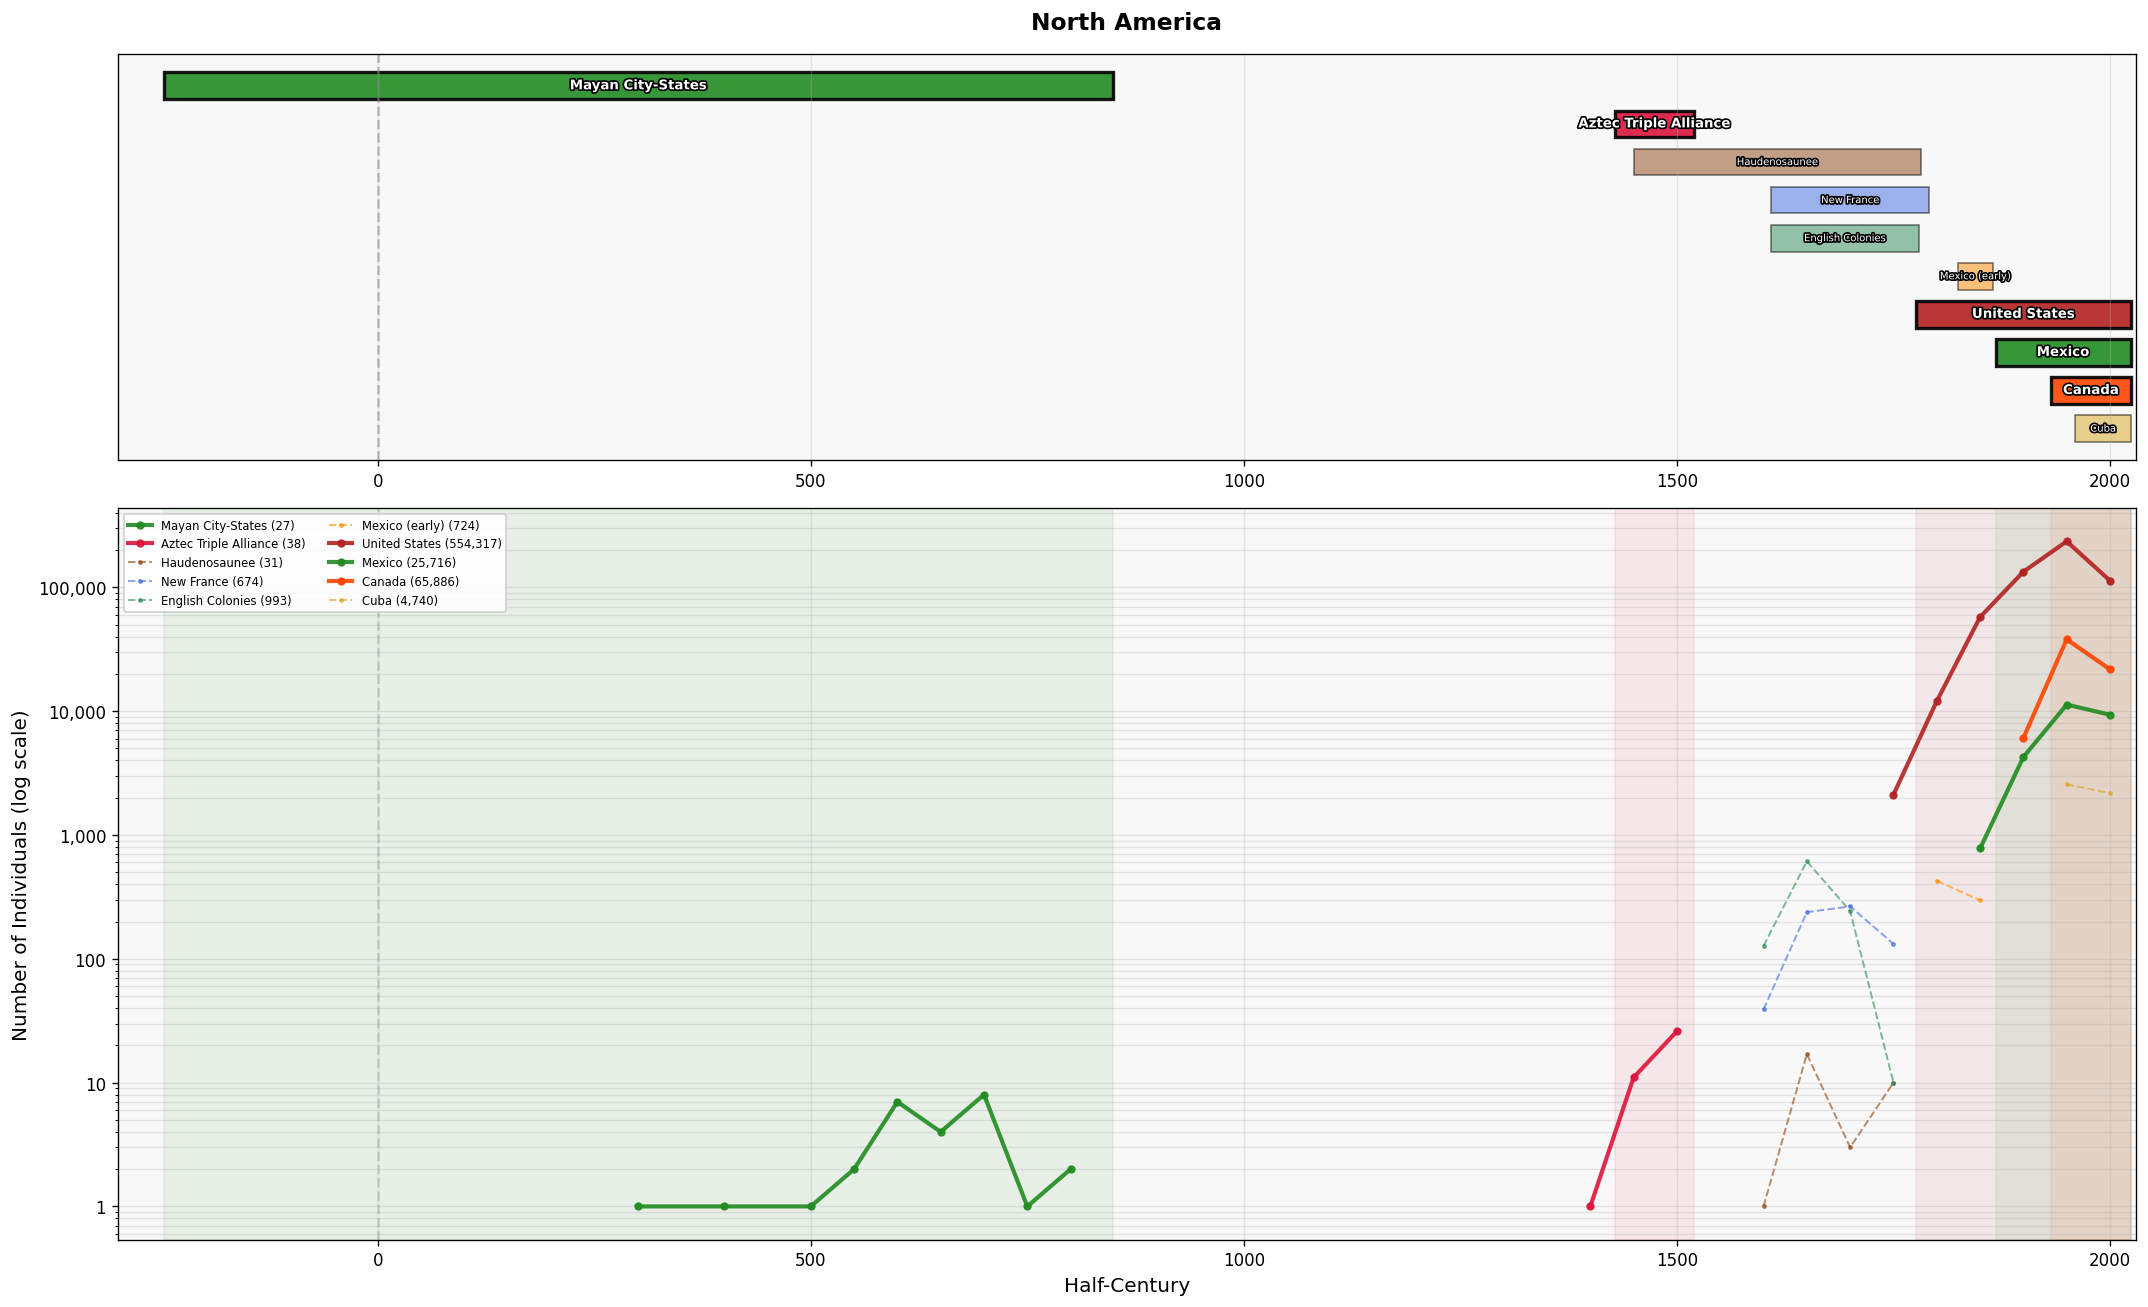

In [20]:
plot_timeline_and_lines(na_data, 'North America', (-300, 2030), save_name='09_north_america.png')

---
## 10. South America

In [21]:
south_america = [
    (940,  'Inca Empire',           '#FF8C00', True),
    (1266, 'Empire of Brazil',      '#228B22', True),
    (1267, 'Gran Colombia',         '#DC143C', True),
    (1234, 'Republic of Chile',     '#B22222', False),
    (1270, 'Republic of Peru',      '#DAA520', False),
    (1283, 'Venezuela',             '#4169E1', False),
    (1274, 'Bolivia',               '#8B4513', False),
    (1286, 'Argentine Confed.',     '#FF4500', False),
    (1278, 'Uruguay',               '#9370DB', False),
    (1285, 'Republic of Ecuador',   '#20B2AA', False),
    (1230, 'Paraguay',              '#556B2F', False),
    (1359, 'Brazilian Republic',    '#2E8B57', True),
    (1414, 'Argentine Republic',    '#CD853F', True),
]
sa_data = load_region_data(conn, south_america)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Inca Empire                   1440 CE - 1571 CE            77       3
* Empire of Brazil              1822 CE - 1889 CE         3,003       2
* Gran Colombia                 1822 CE - 1833 CE           142       1


  Republic of Chile             1812 CE - 2024 CE        14,812       5
  Republic of Peru              1822 CE - 2024 CE        10,449       5
  Venezuela                     1834 CE - 2024 CE         7,020       5
  Bolivia                       1825 CE - 2024 CE         2,463       5


  Argentine Confed.             1834 CE - 1929 CE         3,412       3
  Uruguay                       1828 CE - 2024 CE        15,096       5
  Republic of Ecuador           1834 CE - 2024 CE         3,228       5
  Paraguay                      1811 CE - 2024 CE         2,248       5


* Brazilian Republic            1890 CE - 1966 CE        11,201       3
* Argentine Republic            1930 CE - 2024 CE        28,309       3


  Saved: dynasty_plots/10_south_america.png


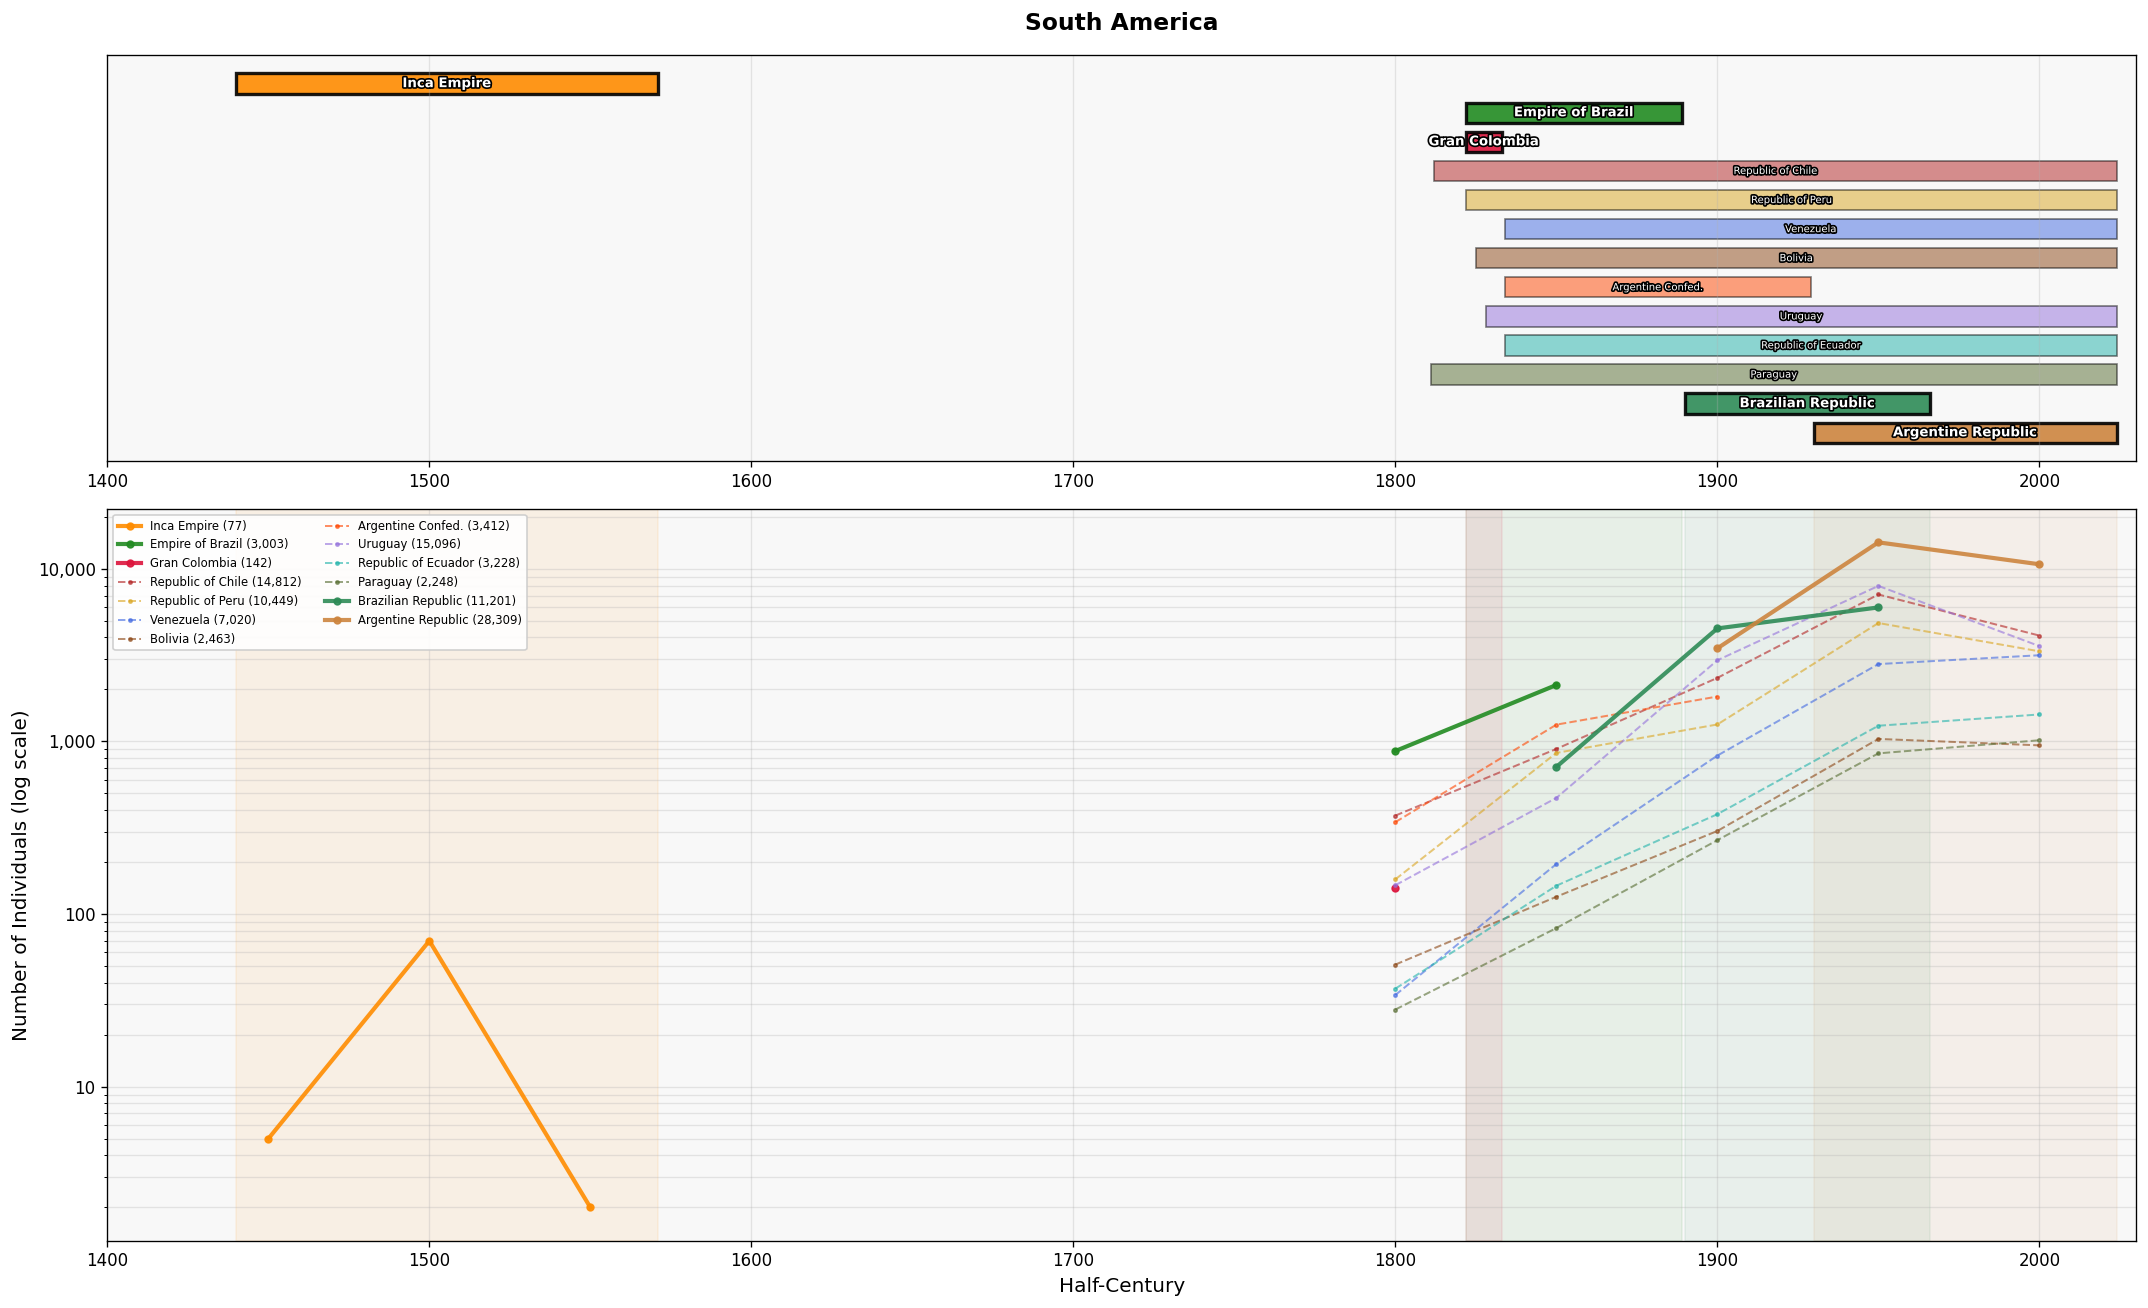

In [22]:
plot_timeline_and_lines(sa_data, 'South America', (1400, 2030), save_name='10_south_america.png')

---
## 11. Oceania

In [23]:
oceania = [
    (1435, 'Australia',    '#FF4500', True),
    (1456, 'New Zealand',  '#228B22', True),
]
oc_data = load_region_data(conn, oceania)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Australia                     1943 CE - 2024 CE        40,207       3


* New Zealand                   1948 CE - 2024 CE        15,001       3


  Saved: dynasty_plots/11_oceania.png


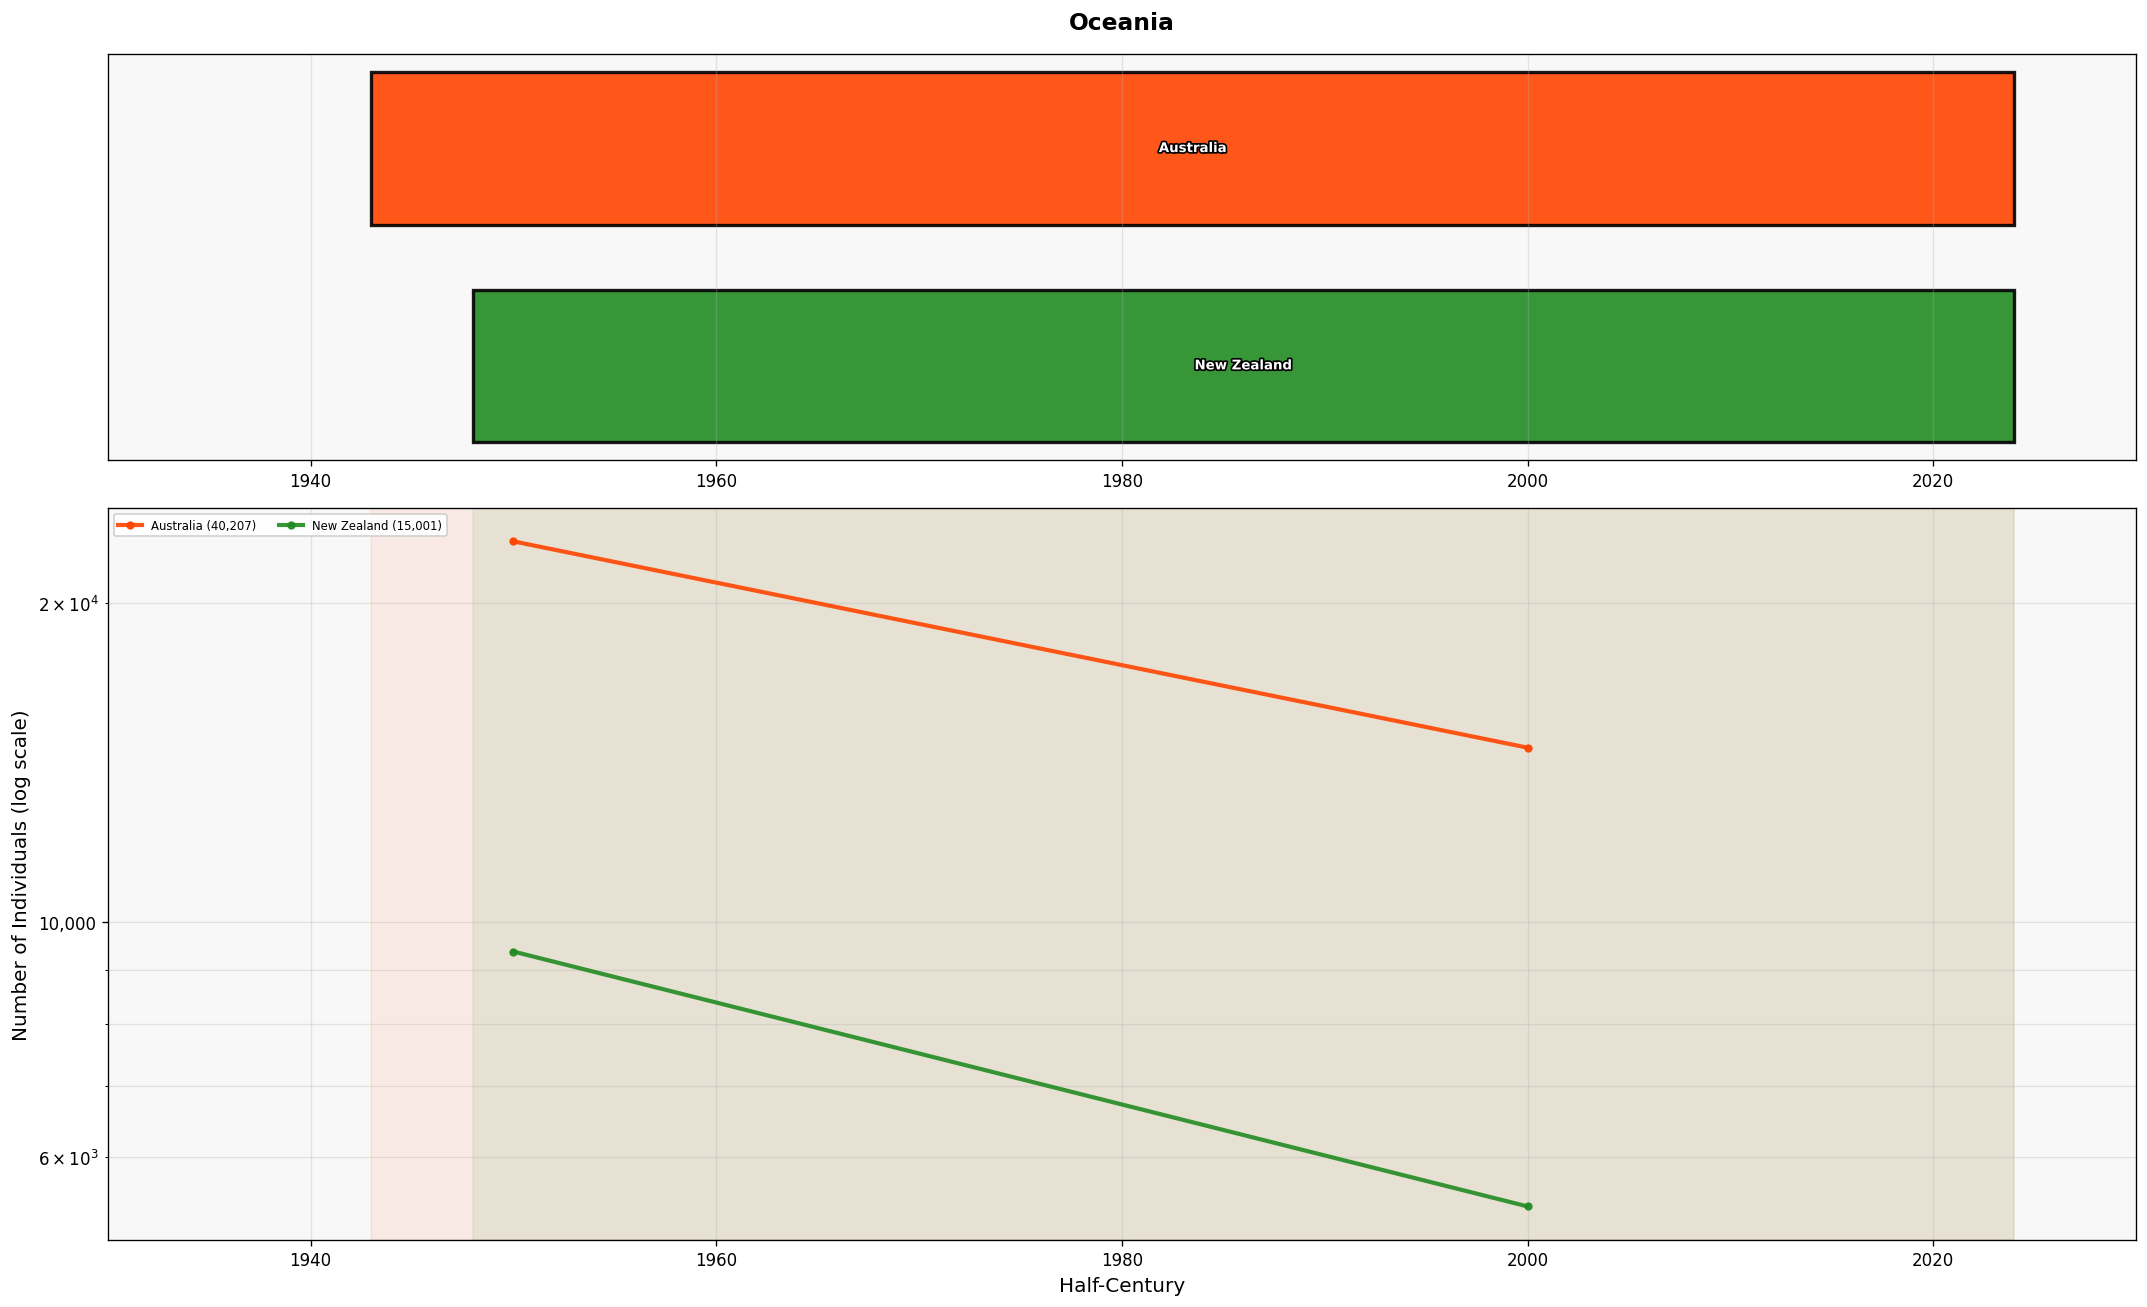

In [24]:
plot_timeline_and_lines(oc_data, 'Oceania', (1930, 2030), save_name='11_oceania.png')

---
## 12. Greek World

In [25]:
greek_world = [
    (22,   'Mycenaean Greece',       '#8B4513', False),
    (35,   'Greek City-States',      '#4169E1', True),
    (61,   'Macedonian Empire',      '#DAA520', True),
    (115,  'Ptolemaic Kingdom',      '#228B22', False),
    (125,  'Seleucid Empire',        '#9370DB', False),
    (142,  'Antigonid Macedonia',    '#708090', False),
    (138,  'Achaean League',         '#CD853F', False),
    (1269, 'First Hellenic Republic','#DC143C', True),
    (1438, 'Kingdom of Greece',      '#FF8C00', False),
    (1553, 'Third Hellenic Republic','#2E8B57', True),
]
gw_data = load_region_data(conn, greek_world)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Mycenaean Greece              1500 BCE - 1101 BCE             1       1
* Greek City-States             800 BCE - 83 CE            627      17
* Macedonian Empire             675 BCE - 292 BCE           148       7
  Ptolemaic Kingdom             331 BCE - 28 BCE           133       7
  Seleucid Empire               318 BCE - 64 BCE           105       6
  Antigonid Macedonia           277 BCE - 165 BCE            63       3
  Achaean League                279 BCE - 145 BCE            15       3
* First Hellenic Republic       1822 CE - 1940 CE         5,669       3
  Kingdom of Greece             1945 CE - 1966 CE         3,022       2
* Third Hellenic Republic       1976 CE - 2024 CE        11,442       2


  Saved: dynasty_plots/12_greek_world.png


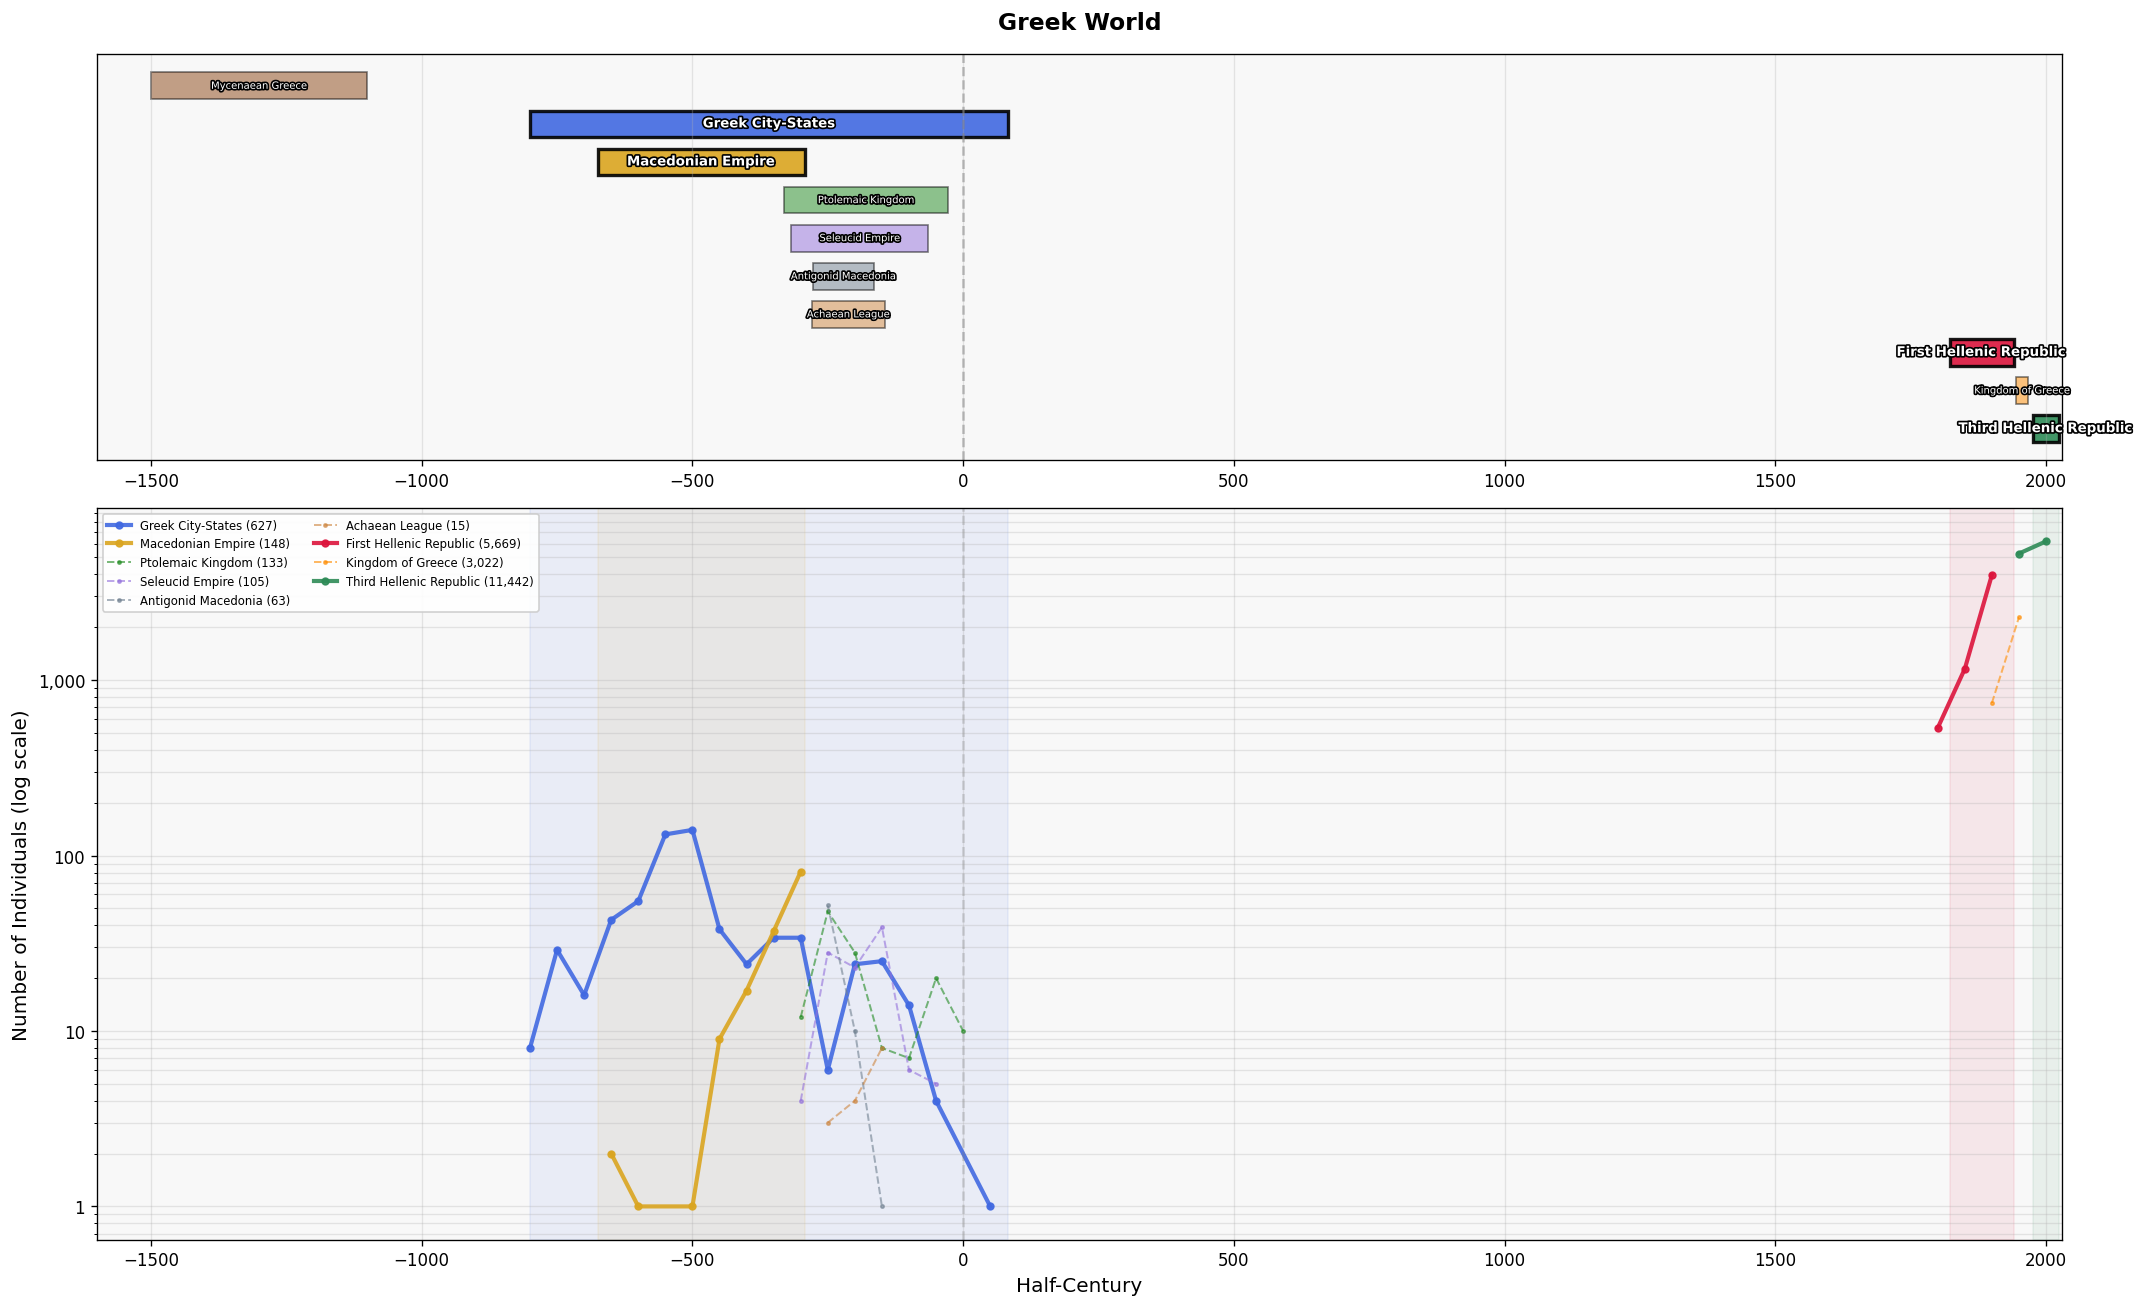

In [26]:
plot_timeline_and_lines(gw_data, 'Greek World', (-1600, 2030), save_name='12_greek_world.png')

---
## 13. Roman / Latin World

In [27]:
roman_world = [
    (41,   'Etruscans',              '#8B4513', False),
    (91,   'Roman Republic',          '#8B0000', True),
    (208,  'Roman Empire',            '#DC143C', True),
    (275,  'Western Roman Empire',    '#CD5C5C', False),
    (274,  'Eastern Roman Empire',    '#B22222', True),
    (380,  'Byzantine Empire',        '#9370DB', True),
]
rw_data = load_region_data(conn, roman_world)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Etruscans                     750 BCE - 265 BCE           103       8
* Roman Republic                500 BCE - 32 BCE         1,707       8
* Roman Empire                   31 BCE - 394 CE         4,245       8
  Western Roman Empire           395 CE - 475 CE           280       3
* Eastern Roman Empire           395 CE - 632 CE           366       6
* Byzantine Empire               633 CE - 1474 CE           417      18


  Saved: dynasty_plots/13_roman_world.png


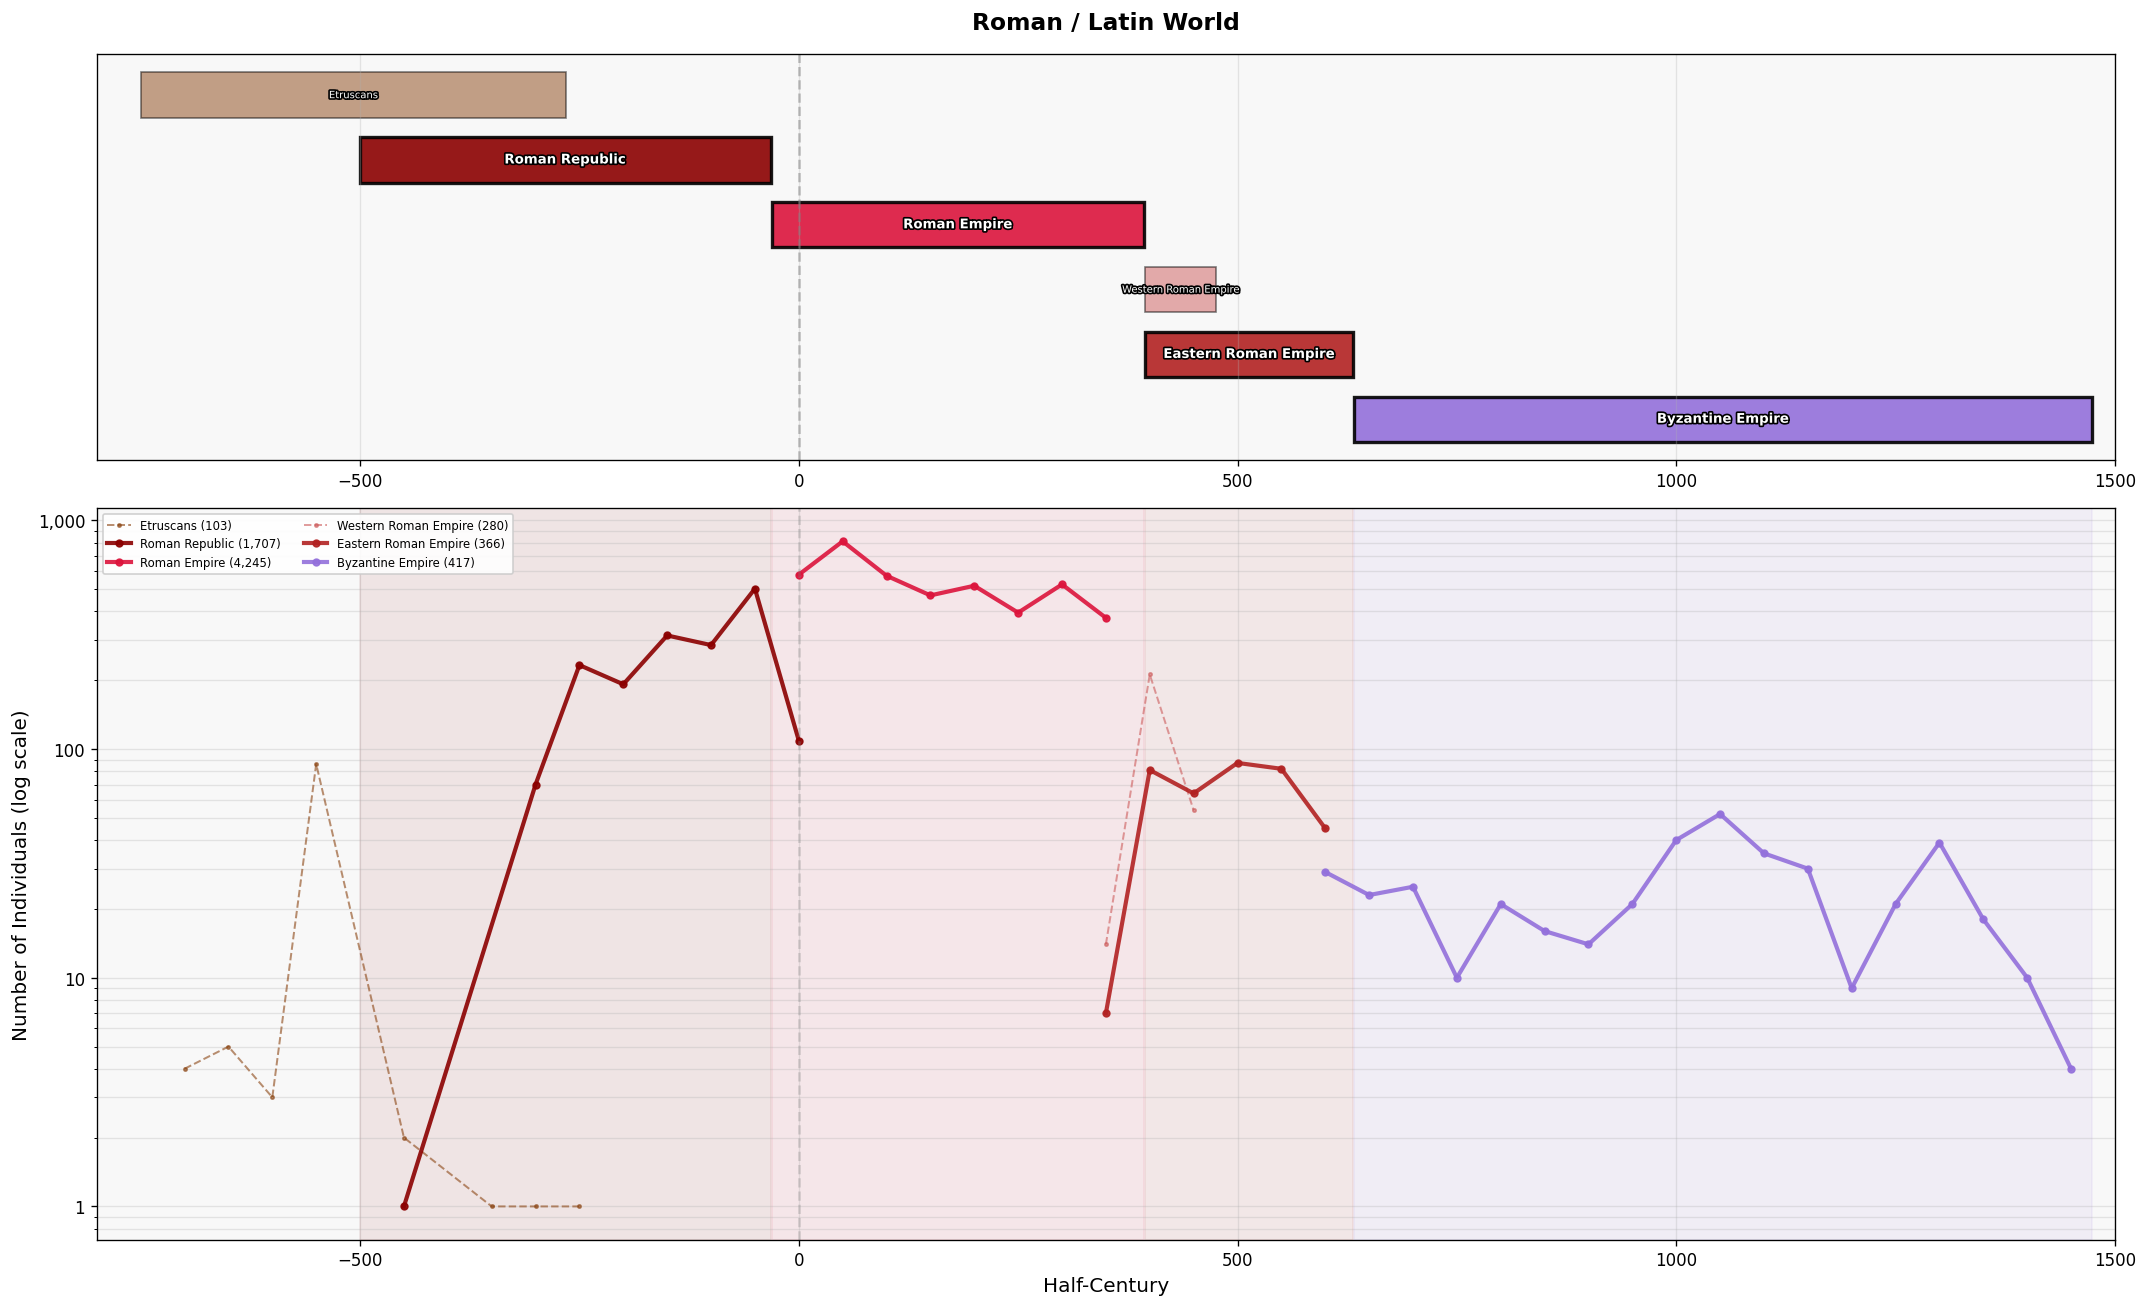

In [28]:
plot_timeline_and_lines(rw_data, 'Roman / Latin World', (-800, 1500), save_name='13_roman_world.png')

---
## 14. Chinese World

In [29]:
chinese_world = [
    (20,   'Shang Dynasty',               '#8B4513', False),
    (27,   'Zhou Dynasty',                 '#CD853F', False),
    (153,  'Qin Dynasty',                  '#FF8C00', False),
    (173,  'Han Dynasty',                  '#DC143C', True),
    (232,  'Cao Wei (Three Kingdoms)',      '#708090', False),
    (267,  'Northern Wei',                 '#556B2F', False),
    (355,  'Sui Dynasty',                  '#DAA520', False),
    (371,  'Tang Dynasty',                 '#4169E1', True),
    (559,  'Northern Song',                '#228B22', True),
    (616,  'Southern Song',                '#2E8B57', True),
    (808,  'Yuan Dynasty',                 '#B22222', True),
    (900,  'Ming Dynasty',                 '#FF4500', True),
    (1083, 'Qing Dynasty',                 '#9370DB', True),
    (1373, 'Republic of China',            '#20B2AA', True),
    (1465, "People's Republic of China",   '#8B0000', True),
]
cw_data = load_region_data(conn, chinese_world)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Shang Dynasty                 1600 BCE - 1001 BCE             8       5
  Zhou Dynasty                  1000 BCE - 751 BCE            16       4
  Qin Dynasty                   218 BCE - 209 BCE            45       1
* Han Dynasty                   202 BCE - 237 CE         1,011       9
  Cao Wei (Three Kingdoms)       224 CE - 264 CE           152       2
  Northern Wei                   387 CE - 533 CE           342       3
  Sui Dynasty                    587 CE - 627 CE           664       2


* Tang Dynasty                   623 CE - 910 CE        25,404       7
* Northern Song                  961 CE - 1027 CE           686       2
* Southern Song                 1028 CE - 1278 CE         6,114       6
* Yuan Dynasty                  1294 CE - 1374 CE         2,217       3
* Ming Dynasty                  1375 CE - 1644 CE        16,932       6


* Qing Dynasty                  1645 CE - 1911 CE        30,119       7
* Republic of China             1912 CE - 2024 CE        21,669       3


* People's Republic of China    1950 CE - 2024 CE        42,757       2


  Saved: dynasty_plots/14_chinese_world.png


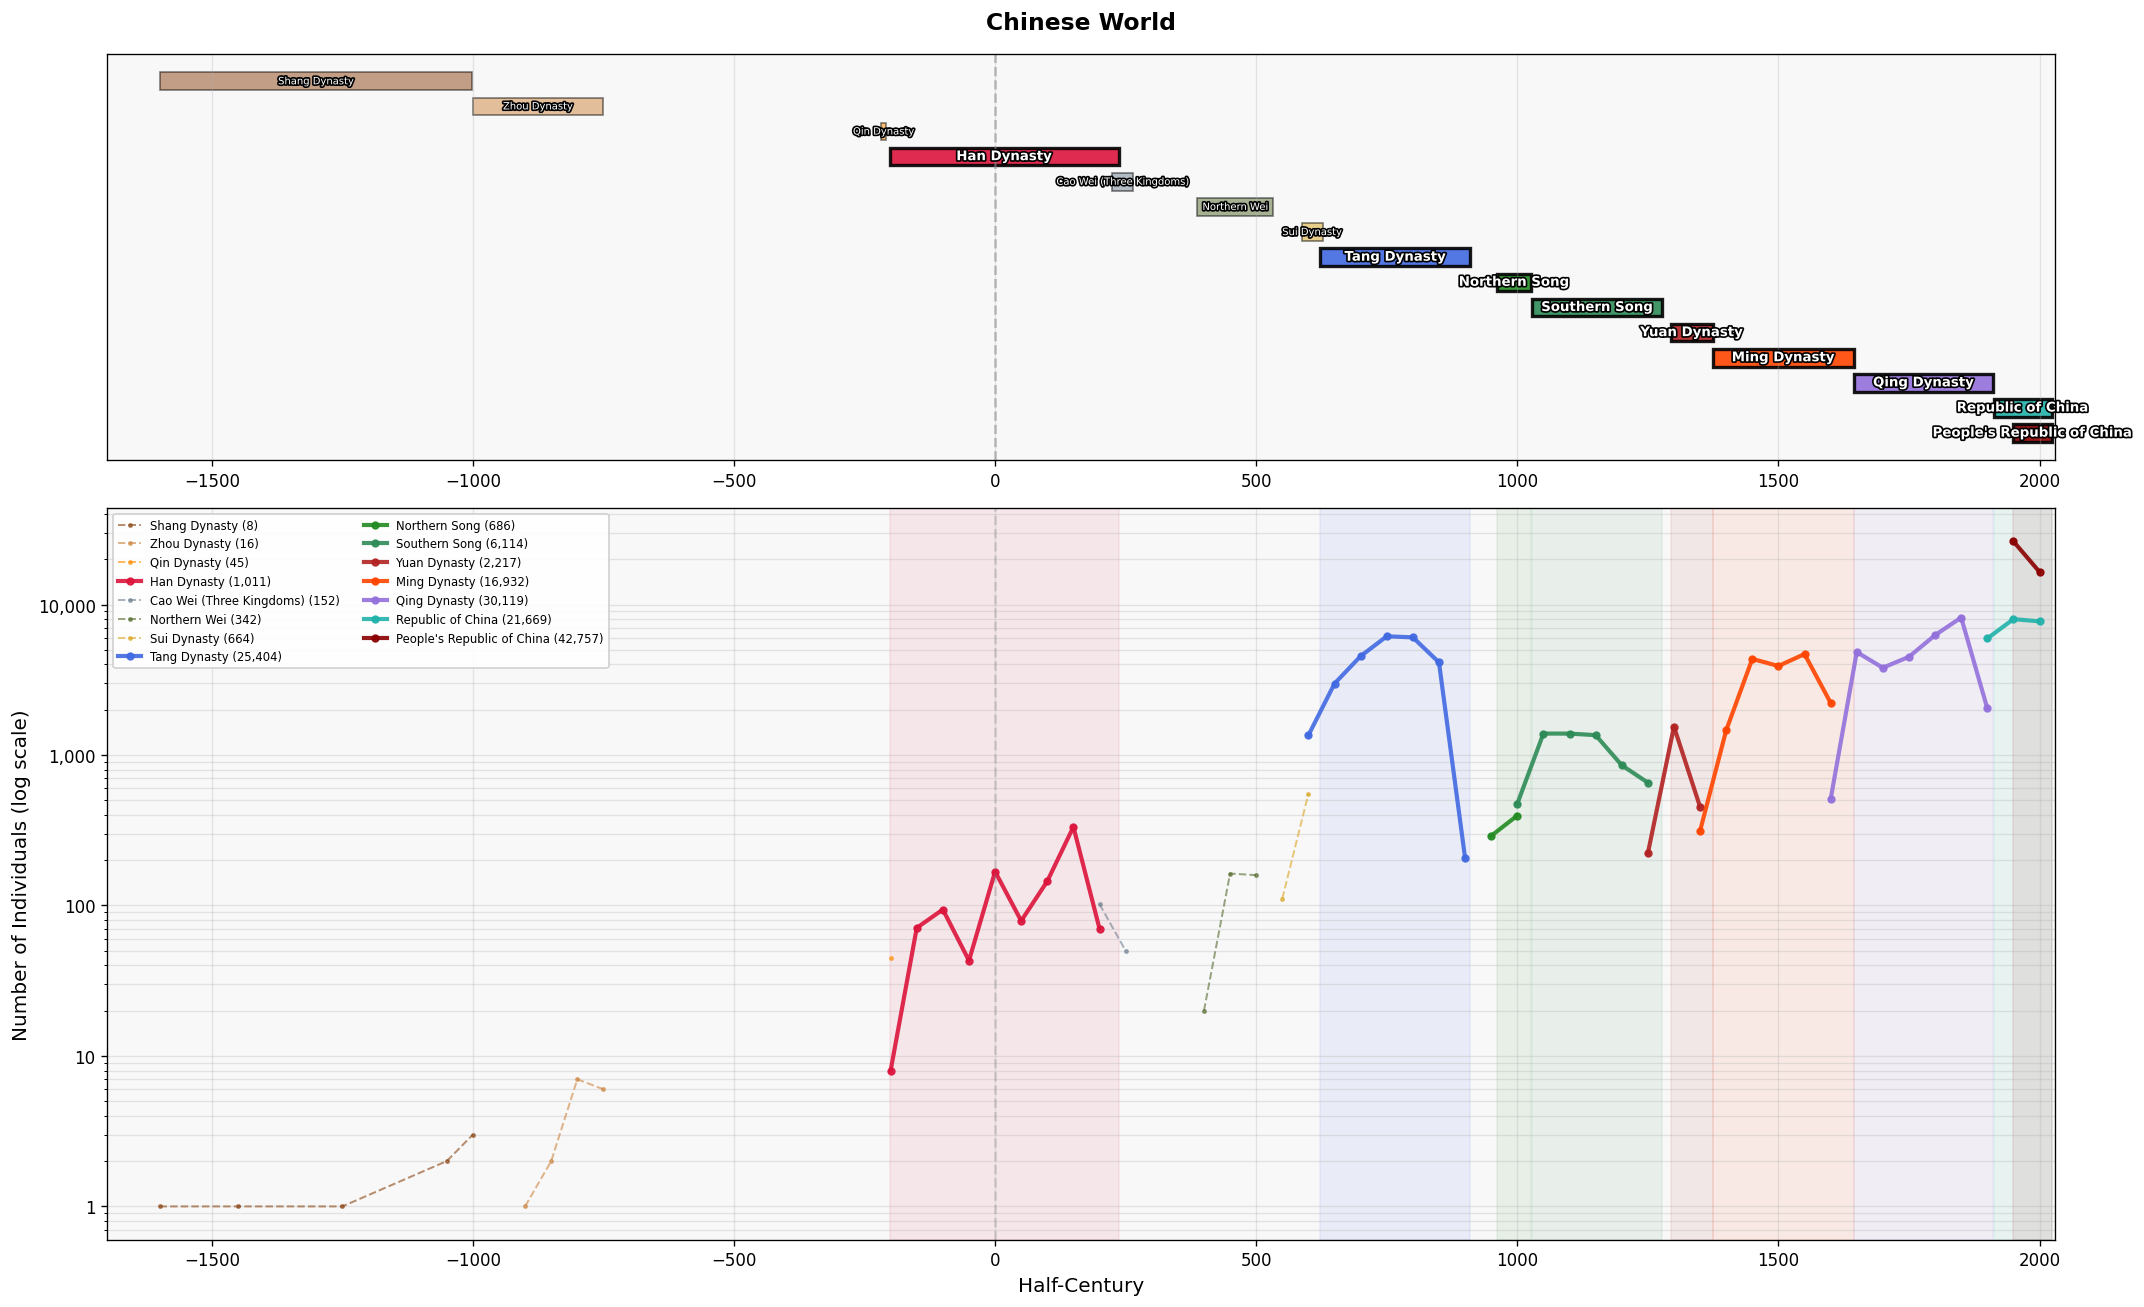

In [30]:
plot_timeline_and_lines(cw_data, 'Chinese World', (-1700, 2030), save_name='14_chinese_world.png')

---
## Summary: All Regions Compared

In [31]:
all_regions = [
    ('Western Europe', we_data),
    ('Eastern Europe', ee_data),
    ('Arab & Islamic World', ai_data),
    ('Mesopotamia & Persia', meso_data),
    ('Indian World', india_data),
    ('East Asia (Japan & Korea)', ea_data),
    ('Southeast Asia', sea_data),
    ('Africa', africa_data),
    ('North America', na_data),
    ('South America', sa_data),
    ('Oceania', oc_data),
    ('Greek World', gw_data),
    ('Roman / Latin World', rw_data),
    ('Chinese World', cw_data),
]

print(f"{'Region':<28s}  {'Polities':>9s}  {'Total Individuals':>18s}  {'Earliest':>10s}  {'Latest':>10s}")
print('=' * 90)
for region_name, rdata in all_regions:
    total = sum(d['total'] for d in rdata)
    earliest = min(d['from'] for d in rdata)
    latest = max(d['to'] for d in rdata)
    e_s = f"{abs(earliest)} BCE" if earliest < 0 else f"{earliest} CE"
    l_s = f"{abs(latest)} BCE" if latest < 0 else f"{latest} CE"
    print(f"  {region_name:<26s}  {len(rdata):>9d}  {total:>18,d}  {e_s:>10s}  {l_s:>10s}")

grand = sum(sum(d['total'] for d in rdata) for _, rdata in all_regions)
print('=' * 90)
print(f"  {'GRAND TOTAL':<26s}  {'':>9s}  {grand:>18,d}")

Region                         Polities   Total Individuals    Earliest      Latest
  Western Europe                     18             274,408     500 BCE     2024 CE
  Eastern Europe                     13             334,422      633 CE     1991 CE
  Arab & Islamic World               17              17,243      633 CE     1923 CE
  Mesopotamia & Persia               10                 947    3400 BCE      643 CE
  Indian World                       13              10,960     318 BCE     1947 CE
  East Asia (Japan & Korea)          13              52,851      36 BCE     1945 CE
  Southeast Asia                     17              41,117      197 CE     2024 CE
  Africa                             15                 912    3000 BCE     1935 CE
  North America                      10             653,146     247 BCE     2024 CE
  South America                      13             101,460     1440 CE     2024 CE
  Oceania                             2              55,208     1943 CE     

In [32]:
conn.close()